# Young-Adult Interstate Migration: Policy Incentives, Social Networks, and Capacity Feedback — V8
## A spatial agent-based model with migration chains, housing/job constraints, and robustness tests

**Core question**

> How strong must a geographically targeted housing-and-employment policy be to overcome young adults' social attachment, and when do migration chains and local capacity constraints amplify or offset that response?

This revision adds two forms of robustness requested in the model review: **social-threshold sensitivity** and **network-homophily sensitivity**. It also adds a lagged **rent response to excess housing demand** so housing pressure affects next-year migration utility rather than appearing only as a hard capacity rejection.

The former `happiness` measure is renamed **social utility index**. It is a transparent model-internal composite score, not a validated subjective-well-being survey measure. Its role is diagnostic rather than a real-world welfare ranking.

**V7 review-closure revision.** This version closes the remaining high-priority review comments: mover-level unit consistency, a soft housing-capacity mechanism with lagged rent feedback, a main-horizon ACS move-rate calibration, a wider policy-intensity sweep, an external-competition scope audit using ACS PUMS, a Tulsa Remote monetary-reference diagnostic, and an explicit BRFSS coverage audit. Optional full geography expansion to Oklahoma/West Virginia is deliberately not mixed into the main eight-state model because it would require a new state-space and IRS-route recalibration; it is documented as external-validation future work rather than presented as completed evidence.


### Reproducible results build

This notebook displays the **fully simulated results** cached in `data/results/`; the empirical inputs it uses are in `data/raw/`. The model and experiment code lives in `src/` (model, data, calibration, experiment runners) and `utils/` (statistics and plotting helpers), and is imported below. Loading the saved seed-level outputs lets the figures and tables be reproduced quickly without rerunning hundreds of ABM realizations; Section 13.6 re-simulates a sample of cases live to confirm the cache matches the code.

In [1]:
import sys
import warnings
from pathlib import Path

# Make the repository root importable whether the notebook is run from notebooks/ or the root.
ROOT = Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import (
    RAW_DATA_DIR, RESULTS_DIR, RANDOM_SEED, STATE_CODES, STATE_NAMES,
    CROSS_SEEDS, SWEEP_SEEDS,
    STANDARD_INTENSITY, EXTENDED_INTENSITIES, SWEEP_INTERACTIONS, LEVERS, NETWORK_DECAYS,
)
from utils.stats import (
    mean_t_ci, power_summary, hill_with_baseline, fit_hill,
    thresholds_by_seed, saturation_table, strong_minus_weak,
)
from utils.analysis import (
    BARTIK_BUT_FOR_LOW, BARTIK_BUT_FOR_HIGH,
    intensity_to_dollar_equivalent, minmax, net_benefit, seed_column, compare,
)
from utils.plotting import INTERACTION_COLORS, spread_labels

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 170)

print("Environment ready.")

Environment ready.


## 1. Empirical state inputs

In [2]:
# State inputs are read from data/raw/state_inputs.csv; derived indices are built in src/data.py.
from src.data import real_raw_data, state_data

## 2. Spatial environment and IRS route calibration

In [3]:
# State coordinates (data/raw/state_coords.csv) give the haversine distance matrix;
# IRS route counts (data/raw/irs_routes.csv) give the observed origin-destination shares.
from src.data import STATE_COORDS, distance_km, distance_index, irs_flows, irs_flow_matrix

In [4]:
# Route calibration (src/calibration.py): fit on six origins, validate on IL and WA, then refit on all eight.
from src.calibration import validation_table, final_route_metrics, CALIBRATED_BETA, DESTINATION_EFFECTS

print("IRS calibration / holdout validation")
display(validation_table.round(3))
print("Final all-route correlation:", round(final_route_metrics["correlation"], 3))

IRS calibration / holdout validation


,model,sample,weighted_rmse,weighted_mae,correlation
0,Prior specification,train,0.113,0.090,-0.143
1,Calibrated on train,train,0.083,0.066,0.705
2,Prior specification,holdout,0.134,0.109,-0.034
3,Calibrated on train,holdout,0.116,0.092,0.589


Final all-route correlation: 0.693


### Spatial view of the empirical eight-state migration system

The model is spatial rather than a collection of abstract rows. The figure below places the eight states at approximate geographic coordinates, sizes nodes by the young-adult population proxy, and draws the largest observed IRS interstate routes. This is a descriptive data figure, not a simulated map.

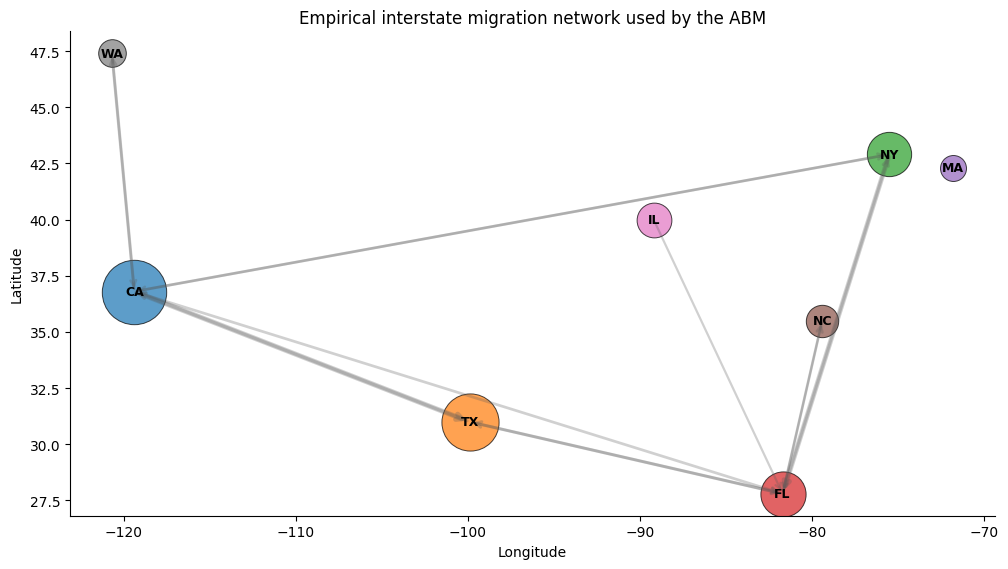

In [5]:
# Real-world spatial presentation of the empirical migration network.
top_routes = irs_flows.nlargest(14, "returns").copy()
max_flow = top_routes["returns"].max()
pop = state_data["young_adult_population_est_18_35"]
pop_size = 350 + 1800 * (pop - pop.min()) / max(pop.max() - pop.min(), 1)

fig, ax = plt.subplots(figsize=(10.2, 5.8))
for _, row in top_routes.iterrows():
    o, d = row["origin"], row["destination"]
    y1, x1 = STATE_COORDS[o]
    y2, x2 = STATE_COORDS[d]
    lw = 0.6 + 3.0 * row["returns"] / max_flow
    ax.annotate(
        "", xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", lw=lw, alpha=0.28, color="0.35"),
    )

for state in STATE_CODES:
    lat, lon = STATE_COORDS[state]
    ax.scatter(lon, lat, s=pop_size[state], alpha=0.72, edgecolor="black", linewidth=0.7)
    ax.text(lon, lat, state, ha="center", va="center", fontsize=9, fontweight="bold")

ax.set_title("Empirical interstate migration network used by the ABM")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Exact ACS PUMS calibration of the overall interstate-move rate

The notebook now **downloads the required 2023 ACS 1-year PUMS person files automatically from the U.S. Census Bureau** when they are not already available locally.

The empirical calibration workflow is:

1. download the eight official state person ZIP files used by this model (CA, TX, NY, FL, MA, NC, IL, WA);
2. read only `AGEP`, `PWGTP`, `MIG`, `MIGSP`, and current-state `STATE/ST` in chunks;
3. keep exact ages **18–35**;
4. identify interstate movers as `MIG == 3`, with a valid previous-state FIPS code and `MIGSP != current state`;
5. weight observations using `PWGTP`;
6. write a small fixed local calibration snapshot so later runs are reproducible and do not need to redownload the microdata.

The eight-state weighted rate is the primary calibration target because the ABM itself contains those eight current-residence states. The raw PUMS ZIP files are cached locally in `pums_2023_1year/` and are not redownloaded if they already exist.

`STRICT_EMPIRICAL_CALIBRATION = True`: the final experiment will not silently replace the observed target with a guessed 5% value.

In [6]:
# Load the exact empirical mobility anchor produced from the eight official 2023 ACS 1-year PUMS person files.
ACS_LOCAL_PATH = RAW_DATA_DIR / "acs_young_adult_interstate_move_rate.csv"
ACS_BY_STATE_PATH = RAW_DATA_DIR / "acs_young_adult_interstate_move_rate_by_state.csv"
ACS_BY_AGE_PATH = RAW_DATA_DIR / "acs_young_adult_interstate_move_rate_by_age.csv"
anchor = pd.read_csv(ACS_LOCAL_PATH).iloc[0]
MOVE_RATE_TARGET = float(anchor["move_rate"])
MOVE_RATE_INFO = {"rate": MOVE_RATE_TARGET, "status": anchor["source"], "scope": anchor["scope"], "empirical": True}
print("Observed ACS 18–35 interstate move-rate target:", round(MOVE_RATE_TARGET, 5))
print("Source:", MOVE_RATE_INFO["status"])
print("Scope:", MOVE_RATE_INFO["scope"])
display(pd.DataFrame([anchor]).drop(columns=["source_files"], errors="ignore").round(5))

Observed ACS 18–35 interstate move-rate target: 0.03875
Source: 2023 ACS 1-year PUMS person records; exact ages 18–35; PWGTP-weighted; scope=eight modeled states
Scope: eight modeled states


,year,age_min,age_max,move_rate,weighted_population,weighted_interstate_movers,unweighted_population,unweighted_interstate_movers,scope,source
0,2023,18,35,0.03875,36550523.0,1416178.0,334763,14273,eight modeled states,2023 ACS 1-year PUMS person records; exact age...


### 3.1 External-competition scope audit (ACS PUMS)

The main ABM intentionally models eight states. To quantify the closed-system limitation rather than hide it, V7 measures what share of observed 2023 interstate in-movers to those eight states previously lived in one of the other U.S. states. This is an **empirical scope diagnostic**, not a new calibrated destination model. A full `OTHER_US` utility option would require nationwide destination-flow calibration and would change the estimand, so it is not silently inserted into the main model.


Weighted share of interstate in-movers originating outside the eight modeled states: 0.620


,state,external_origin_share
0,CA,0.584
4,MA,0.595
2,NY,0.600
7,WA,0.600
3,FL,0.626
1,TX,0.637
5,NC,0.644
6,IL,0.682


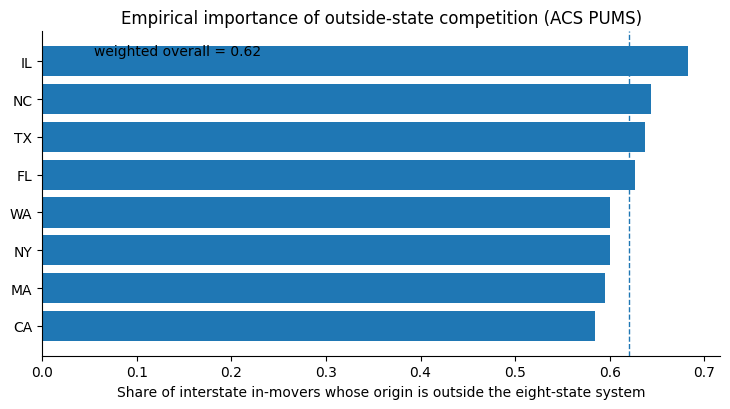

In [7]:
external_origin_by_state = pd.read_csv(RAW_DATA_DIR / "pums_external_origin_competition.csv")
EXTERNAL_ORIGIN_SHARE = (
    external_origin_by_state["weighted_from_other_us"].sum()
    / external_origin_by_state["weighted_interstate_inmovers"].sum()
)
print(f"Weighted share of interstate in-movers originating outside the eight modeled states: {EXTERNAL_ORIGIN_SHARE:.3f}")
display(external_origin_by_state[["state","external_origin_share"]].sort_values("external_origin_share").round(3))

fig, ax = plt.subplots(figsize=(7.4, 4.2))
g = external_origin_by_state.sort_values("external_origin_share")
ax.barh(g["state"], g["external_origin_share"])
ax.axvline(EXTERNAL_ORIGIN_SHARE, linestyle="--", linewidth=1, label=f"weighted overall = {EXTERNAL_ORIGIN_SHARE:.2f}")
ax.set_xlabel("Share of interstate in-movers whose origin is outside the eight-state system")
ax.set_title("Empirical importance of outside-state competition (ACS PUMS)")
ax.legend(frameon=False)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 4. Policy, interaction, demography, and shock parameters

In [8]:
# Mortality table, PARAMS, shock scenarios, policy tables and the focal-state rule are in src/parameters.py.
from src.parameters import PARAMS, SHOCK_SCENARIOS, policy_table, mortality_probability, FOCAL_STATE

print("Focal policy state:", FOCAL_STATE, STATE_NAMES[FOCAL_STATE])

Focal policy state: NY New York


## 5. Agent initialization and network-structure robustness

The default initial condition remains deliberately mixed: current state and home state are sampled independently. Two distinct robustness mechanisms are now separated:

- `network_homophily_share`: share of each agent's initial contacts preferentially drawn from the same home-state group. Default `0.0` preserves the original random-network baseline; `0.5` is tested as a structured-network alternative.
- `entrant_home_local` / `entrant_network_home_bias`: replacement-entrant assumptions retained from earlier versions and tested separately.

This distinction matters because a model should not label clustering as an emergent result if it was mechanically inserted by initialization.

In [9]:
# Agent attributes, couples and the initial contact network: src/agents.py
from src.agents import initialise_agents

## 6. Interaction-driven ABM

The model combines household migration choice, social-network influence, finite housing and jobs, demographic turnover, and state-level environmental feedback. Housing is now represented as a **hybrid quantity-price constraint**: capacity can still reject excess households in the current year, but the state-specific rejection rate raises next-year rents through `rent_rejection_elasticity`. This makes excess demand partially self-correcting instead of producing only a mechanical capacity wall.

In [10]:
# The full model (demography, household formation, migration choice, housing and job
# matching, environment feedback and metrics) is the PolicySocialABM class in src/model.py.
from src.model import PolicySocialABM

## 7. Calibrate the overall move level

In [11]:
move_rate_calibration = pd.read_csv(RESULTS_DIR / "move_rate_calibration.csv")
best = move_rate_calibration.sort_values("absolute_error").iloc[0]
PARAMS["beta_current_state"] = float(best["beta_current_state"])
display(move_rate_calibration.round(5))
print("Calibrated beta_current_state:", round(PARAMS["beta_current_state"], 4))
print("Closest simulated rate:", round(float(best["simulated_move_rate"]), 5))

,beta_current_state,simulated_move_rate,target_move_rate,absolute_error
0,3.875,0.03924,0.03875,0.00049
1,3.900,0.03847,0.03875,0.00027
2,3.925,0.03861,0.03875,0.00013


Calibrated beta_current_state: 3.925
Closest simulated rate: 0.03861


## 8. Step 1 - no-policy reality baseline

The baseline uses 20 annual rounds and eight seeds. It reports mobility, clustering, housing pressure, unfilled jobs, and the **model social utility index**. The index is a model diagnostic assembled from peer co-location, co-origin concentration, home-state attachment, employment, relative income, and affordability; it should not be interpreted as a validated subjective-well-being survey score.

In [12]:
baseline_runs = pd.read_csv(RESULTS_DIR / "baseline_runs.csv")
baseline_summary = baseline_runs.agg(["mean", "std"]).T
display(baseline_summary.loc[[
    "move_rate", "coorigin_clustering", "peer_colocation",
    "housing_rejection", "mean_social_utility_index", "unfilled_jobs"
]].round(3))
print(f"Baseline mean move rate = {baseline_runs['move_rate'].mean():.4f}; ACS calibration target = {MOVE_RATE_TARGET:.4f}.")

,mean,std
move_rate,0.041,0.002
coorigin_clustering,0.165,0.007
peer_colocation,0.170,0.010
housing_rejection,0.018,0.008
mean_social_utility_index,0.341,0.004
unfilled_jobs,0.100,0.076


Baseline mean move rate = 0.0413; ACS calibration target = 0.0387.


## 9. Step 2 — targeted policy × social-tie strength

A single focal state receives the intervention. The cross experiment separates housing policy, employment policy, and a combined package. Every active policy also contains a direct migration incentive term so the model can test how much explicit pull is needed to overcome local social attachment.

In [13]:
# INTERACTION_LEVELS, POLICY_TYPES and STANDARD_INTENSITY are set in src/config.py.
cross_runs = pd.read_csv(RESULTS_DIR / "cross_experiment_runs.csv")
cross_summary = pd.read_csv(RESULTS_DIR / "cross_experiment_summary.csv")
display(cross_summary.round(3))

,interaction,policy,target_inflow_rate,mover_origin_attachment,social_cost,chain_share,housing_rejection,job_rejection,clustering,peer_colocation,social_utility_index
0,medium,baseline,0.005,0.136,-0.005,0.095,0.008,0.200,0.166,0.169,0.341
1,medium,combined,0.024,0.126,-0.109,0.431,0.119,0.123,0.196,0.211,0.368
2,medium,employment,0.011,0.129,-0.048,0.239,0.104,0.123,0.166,0.175,0.345
3,medium,housing,0.011,0.133,-0.046,0.208,0.008,0.200,0.165,0.173,0.345
4,strong,baseline,0.005,0.120,-0.025,0.135,0.004,0.201,0.172,0.179,0.345
5,strong,combined,0.026,0.119,-0.136,0.457,0.142,0.123,0.213,0.237,0.380
6,strong,employment,0.012,0.122,-0.061,0.240,0.113,0.126,0.170,0.183,0.348
7,strong,housing,0.011,0.120,-0.056,0.212,0.015,0.200,0.175,0.185,0.351
8,weak,baseline,0.005,0.137,0.008,0.134,0.007,0.200,0.158,0.161,0.336
9,weak,combined,0.020,0.129,-0.090,0.341,0.079,0.122,0.186,0.199,0.363


### Policy-effect interaction test

The same seed is compared with and without policy, then the policy effect under strong ties is compared with the policy effect under weak ties. This directly tests whether social interaction dampens or amplifies policy rather than inferring it from separate simulations.

In [14]:
policy_effects = pd.read_csv(RESULTS_DIR / "paired_policy_effects.csv")
interaction_modification = pd.read_csv(RESULTS_DIR / "interaction_modification.csv")
display(interaction_modification.round(4))

,policy,metric,strong_minus_weak_policy_effect,ci95_half_width
0,housing,d_target_inflow_rate,0.0008,0.0017
1,housing,d_target_social_cost,0.0124,0.0255
2,housing,d_target_chain_share,0.0175,0.1284
3,housing,d_coorigin_clustering,-0.0010,0.0109
4,employment,d_target_inflow_rate,0.0012,0.0017
5,employment,d_target_social_cost,0.0058,0.0197
6,employment,d_target_chain_share,0.0593,0.0822
7,employment,d_coorigin_clustering,-0.0043,0.0123
8,combined,d_target_inflow_rate,0.0046,0.0016
9,combined,d_target_social_cost,-0.0117,0.0207


### Power check: are the non-significant interaction effects informative?

The claim that social ties amplify only the combined package rests partly on the housing and employment strong-minus-weak effects being non-significant. That absence is only informative if the design could have detected a meaningful effect. From each effect's 95% interval (paired over the 8 cross-experiment seeds), the cell below reports the **minimum detectable effect** at 80% power and the number of seeds that would be needed for the observed effect to reach 80% power. No new simulations are needed.

In [15]:
power_table = power_summary(policy_effects, n_seeds=len(CROSS_SEEDS))
display(power_table.round(4))
inflow = power_table[power_table["metric"] == "d_target_inflow_rate"].set_index("policy")
print(f"Target inflow: with {len(CROSS_SEEDS)} seeds the design detects strong-minus-weak effects of about "
      f"{inflow['mde_80pct_power'].median():.4f} at 80% power; the combined effect is "
      f"{inflow.loc['combined', 'strong_minus_weak_policy_effect']:.4f}, while housing and employment "
      f"({inflow.loc['housing', 'strong_minus_weak_policy_effect']:.4f}, {inflow.loc['employment', 'strong_minus_weak_policy_effect']:.4f}) "
      f"would need about {inflow.loc['housing', 'seeds_for_observed_effect']:.0f} and {inflow.loc['employment', 'seeds_for_observed_effect']:.0f} seeds.")

,policy,metric,strong_minus_weak_policy_effect,ci95_half_width,mde_80pct_power,seeds_for_observed_effect
0,housing,d_target_inflow_rate,0.0008,0.0017,0.0023,53.0
1,housing,d_target_social_cost,0.0124,0.0255,0.0352,50.0
2,housing,d_target_chain_share,0.0175,0.1284,0.1771,607.0
3,housing,d_coorigin_clustering,-0.0010,0.0109,0.0150,1337.0
4,employment,d_target_inflow_rate,0.0012,0.0017,0.0023,25.0
...,...,...,...,...,...,...
79,employment,NaN,NaN,NaN,NaN,NaN
80,combined,NaN,NaN,NaN,NaN,NaN
81,housing,NaN,NaN,NaN,NaN,NaN
82,employment,NaN,NaN,NaN,NaN,NaN


Target inflow: with 8 seeds the design detects strong-minus-weak effects of about 0.0023 at 80% power; the combined effect is 0.0046, while housing and employment (0.0008, 0.0012) would need about 53 and 25 seeds.


### Visual evidence: policy effects and interaction structure

The forest plot summarizes paired seed-level changes in target inflow relative to the no-policy baseline. The heatmap shows the corresponding mean inflow level for every policy × social-interaction cell.

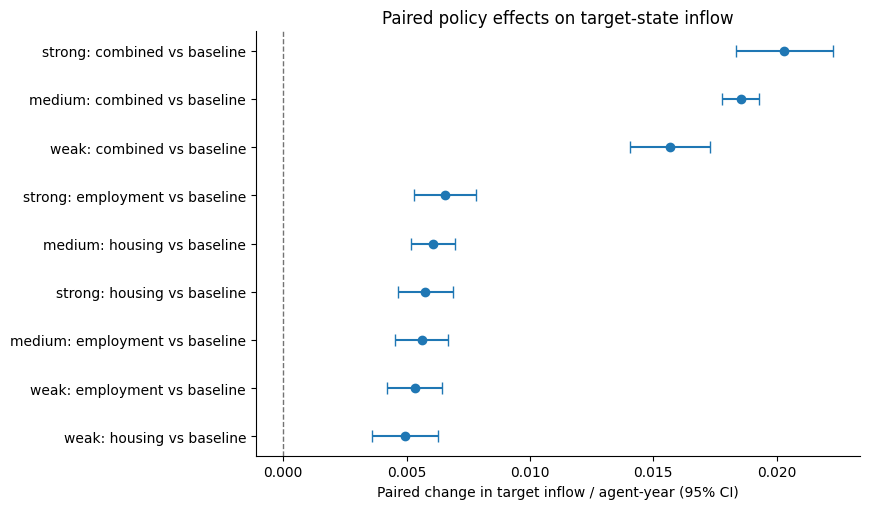

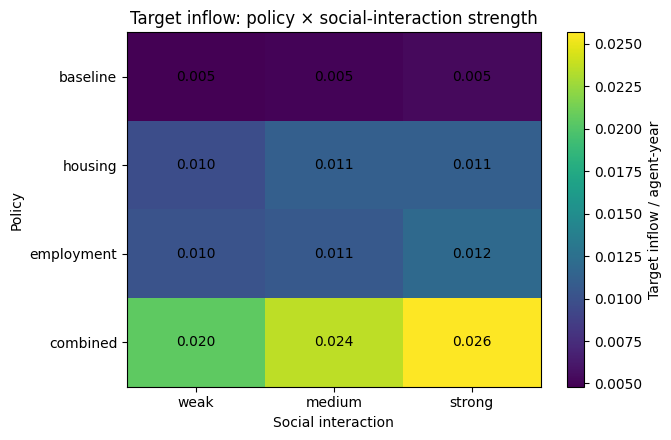

In [16]:
# 1) Forest plot of paired target-inflow effects with 95% t intervals.
forest_rows = []
for (interaction, policy), g in policy_effects.groupby(["interaction", "policy"]):
    effect, ci = mean_t_ci(g["d_target_inflow_rate"])
    forest_rows.append({
        "comparison": f"{interaction}: {policy} vs baseline",
        "effect_mean": effect,
        "effect_ci95": ci,
    })
policy_effect_forest = pd.DataFrame(forest_rows).sort_values("effect_mean")

y = np.arange(len(policy_effect_forest))
fig, ax = plt.subplots(figsize=(8.8, 5.2))
ax.errorbar(
    policy_effect_forest["effect_mean"], y,
    xerr=policy_effect_forest["effect_ci95"],
    fmt="o", capsize=4,
)
ax.axvline(0, color="0.45", linestyle="--", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(policy_effect_forest["comparison"])
ax.set_xlabel("Paired change in target inflow / agent-year (95% CI)")
ax.set_title("Paired policy effects on target-state inflow")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# 2) Policy × social-interaction heatmap.
policy_order = ["baseline", "housing", "employment", "combined"]
interaction_order = ["weak", "medium", "strong"]
pivot = (
    cross_summary.pivot(index="policy", columns="interaction", values="target_inflow_rate")
    .reindex(index=policy_order, columns=interaction_order)
)
fig, ax = plt.subplots(figsize=(6.8, 4.5))
im = ax.imshow(pivot.to_numpy(), aspect="auto")
ax.set_xticks(range(len(pivot.columns)), pivot.columns)
ax.set_yticks(range(len(pivot.index)), pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.iloc[i, j]:.3f}", ha="center", va="center")
fig.colorbar(im, ax=ax, label="Target inflow / agent-year")
ax.set_title("Target inflow: policy × social-interaction strength")
ax.set_xlabel("Social interaction")
ax.set_ylabel("Policy")
plt.tight_layout()
plt.show()

## 10. Policy-intensity sweep and minimum sufficient strength

The combined housing + employment package is scanned in the focal state. The key threshold is the smallest intensity reaching 90% of the maximum observed target-state inflow response. This is a simulation response threshold, not a fiscal cost optimum.

The grid uses 0.5-unit steps from 0 to 4 and adds 5 and 6. Earlier V7 builds stopped at 4.0, and the 90% benchmark sat at 3.0; with the grid extended to 6 it moves to 3.5 (medium ties), so part of the earlier value was right-censoring by the experimental range. `response90_median_grid0to4` reports the threshold recomputed on the old 0–4 grid for comparison.

The combined package is one of four levers in a single sweep batch (housing, employment, cash incentive, combined; Section 10.5), so this section reads the combined rows from that batch rather than running a separate sweep. Its 0–4 rows use the same seeds as the earlier V7 sweep and reproduce it exactly.

### Sweep runner and run-level summary

The run-summary function (`summarise_v7_run` in `src/experiments.py`) is reconstructed from `PolicySocialABM.mechanism_history()` and `history`. The reconstruction was checked against the cached outputs: with the same seeds it reproduces the Section 9 cross-experiment table and the earlier Section 10 threshold table exactly. Two details were recovered in that check:

- `target_inflow_rate` = accepted target-state movers / system agent-years; `housing_rejection` is the **target-state** rejection rate (rejected / proposed moves into the target).
- In the cross experiment every single-lever policy carries a `0.5 × intensity` migration incentive, so the combined package carries `1.0 × intensity`. The single-lever sweep in 10.5 instead uses **pure** levers, so its intensity-1.0 slice is not the Section 9 table.

The model records target-state mechanism counts against the global `FOCAL_STATE`, so the runner temporarily switches that global when another target state is simulated (Section 10.6) and restores it afterwards. Results are read from `RESULT_CACHE` when present; otherwise the runner simulates them (serially this takes a long time).

In [17]:
# Run summaries, policy builders and the cached sweep runner are in src/experiments.py;
# threshold and saturation helpers are in utils/stats.py.
from src.experiments import summarise_v7_run, lever_policy, run_lever_case, cached_or_run

In [18]:
lever_cases = [(FOCAL_STATE, lever, x, inter, seed)
               for lever in LEVERS for x in EXTENDED_INTENSITIES
               for inter in SWEEP_INTERACTIONS for seed in SWEEP_SEEDS]
lever_runs = cached_or_run("lever_intensity_sweep_runs.csv", lever_cases)

POLICY_INTENSITIES = EXTENDED_INTENSITIES
sweep_runs = (lever_runs[lever_runs["lever"] == "combined"]
              .rename(columns={"intensity": "policy_intensity"}).reset_index(drop=True))
sweep_summary = sweep_runs.groupby(["interaction", "policy_intensity"]).agg(
    target_inflow_rate=("target_inflow_rate", "mean"),
    target_inflow_ci95=("target_inflow_rate", lambda s: mean_t_ci(s)[1]),
    target_social_cost=("target_social_cost", "mean"),
    chain_share=("chain_share", "mean"),
    housing_rejection=("housing_rejection", "mean"),
).reset_index()

threshold_by_seed = thresholds_by_seed(sweep_runs, ["interaction"], x_col="policy_intensity")
threshold_grid4 = thresholds_by_seed(sweep_runs[sweep_runs["policy_intensity"] <= 4.0], ["interaction"], x_col="policy_intensity")
threshold_summary = threshold_by_seed.groupby("interaction").agg(
    response90_median=("response90", "median"),
    response90_q25=("response90", lambda s: s.quantile(0.25)),
    response90_q75=("response90", lambda s: s.quantile(0.75)),
    steepest_low_median=("steepest_low", "median"),
    steepest_high_median=("steepest_high", "median"),
).join(threshold_grid4.groupby("interaction")["response90"].median().rename("response90_median_grid0to4")).reset_index()
display(threshold_summary.round(3))

,interaction,response90_median,response90_q25,response90_q75,steepest_low_median,steepest_high_median,response90_median_grid0to4
0,medium,3.50,3.5,3.5,1.75,2.25,3.0
1,strong,3.25,3.0,3.5,2.00,2.50,3.0
2,weak,4.00,3.5,4.0,1.75,2.25,3.5


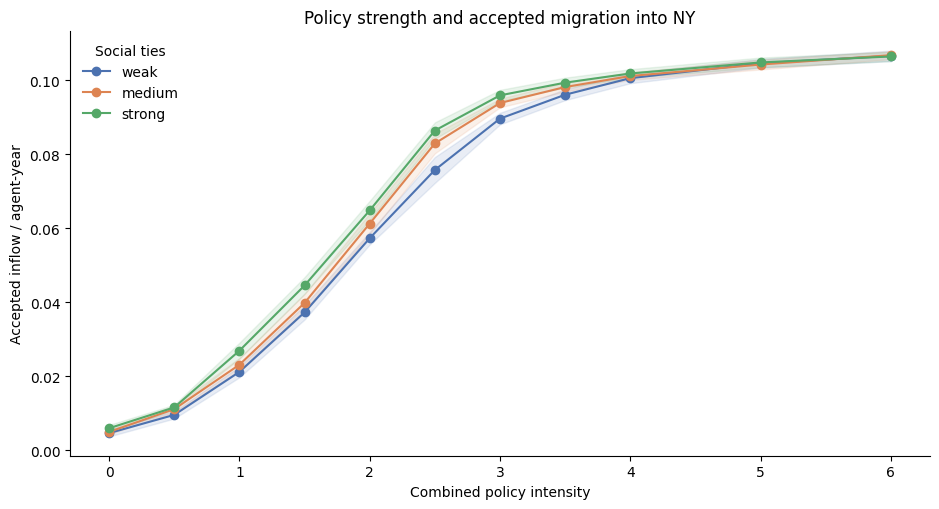

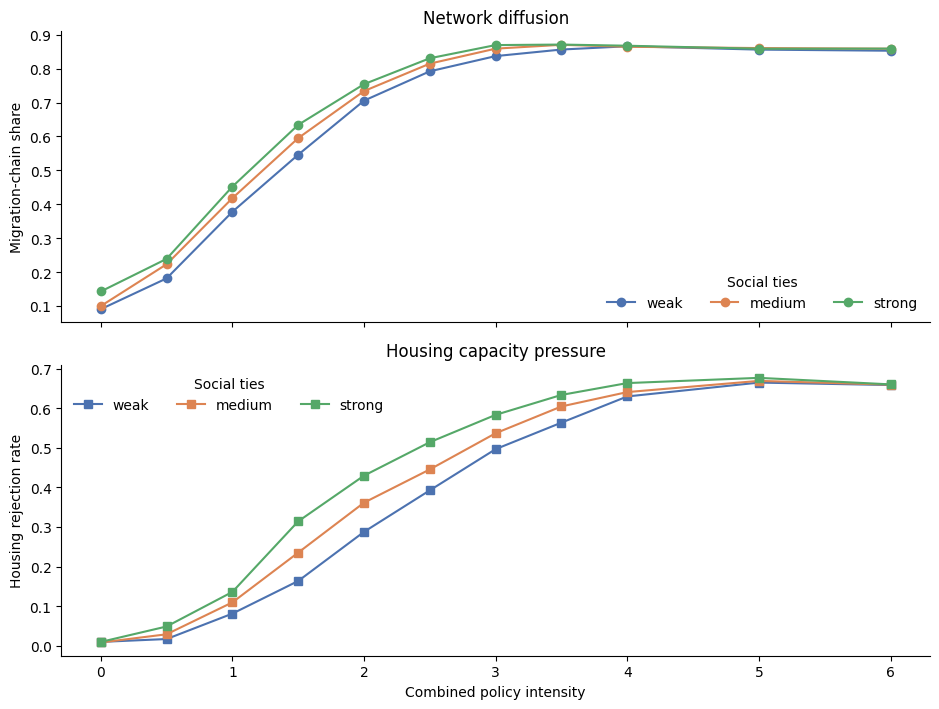

In [19]:
# Main response curve with consistent social-interaction colors.
fig, ax = plt.subplots(figsize=(9.5, 5.2))
for label in ["weak", "medium", "strong"]:
    g = sweep_summary[sweep_summary["interaction"] == label].sort_values("policy_intensity")
    x = g["policy_intensity"].to_numpy()
    y = g["target_inflow_rate"].to_numpy()
    ci = g["target_inflow_ci95"].to_numpy()
    ax.plot(x, y, marker="o", color=INTERACTION_COLORS[label], label=label)
    ax.fill_between(x, y - ci, y + ci, color=INTERACTION_COLORS[label], alpha=0.12)
ax.set_title(f"Policy strength and accepted migration into {FOCAL_STATE}")
ax.set_xlabel("Combined policy intensity")
ax.set_ylabel("Accepted inflow / agent-year")
ax.legend(title="Social ties", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Keep network diffusion and capacity pressure visually paired by color, but
# separate the metrics into two panels so line style is not doing too much work.
fig, axes = plt.subplots(2, 1, figsize=(9.5, 7.2), sharex=True)
for label in ["weak", "medium", "strong"]:
    g = sweep_summary[sweep_summary["interaction"] == label].sort_values("policy_intensity")
    axes[0].plot(
        g["policy_intensity"], g["chain_share"], marker="o",
        color=INTERACTION_COLORS[label], label=label,
    )
    axes[1].plot(
        g["policy_intensity"], g["housing_rejection"], marker="s",
        color=INTERACTION_COLORS[label], label=label,
    )
axes[0].set_title("Network diffusion")
axes[0].set_ylabel("Migration-chain share")
axes[1].set_title("Housing capacity pressure")
axes[1].set_xlabel("Combined policy intensity")
axes[1].set_ylabel("Housing rejection rate")
for ax in axes:
    ax.legend(title="Social ties", frameon=False, ncol=3)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 10.1 Tulsa Remote external-reference diagnostic

To make the policy scale interpretable without pretending that a remote-worker program is representative of all 18–35-year-olds, V7 adds a **reference-only** monetary mapping: one migration-incentive intensity unit is displayed as a `$10,000` equivalent because Tulsa Remote pays selected remote workers $10,000 to move and stay at least one year. Bartik (2025, Upjohn Institute Technical Report 25-050) estimates a 58–70% “but-for” share among Tulsa Remote member households.

The model is **not calibrated to this range**. Instead, a migration-incentive-only experiment reports the analogous simulated induced share `(policy inflow − baseline inflow) / policy inflow`. This is a diagnostic of scale and external plausibility only; population, geography, selection, and accompanying services differ substantially from Tulsa Remote.

Source: W.E. Upjohn Institute, Bartik (2025), *The Effects of Tulsa Remote on Inducing Moves to Tulsa: Estimates and Implications*, DOI 10.17848/tr25-050.


,reference_amount_usd,model_mean_induced_share,model_ci95_halfwidth,bartik_low,bartik_high,interpretation
0,10000,0.396,0.075,0.58,0.7,external reference only; not calibration


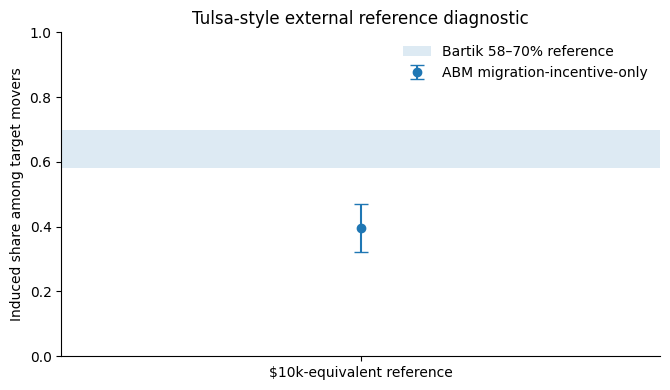

In [20]:
cash_reference_runs = pd.read_csv(RESULTS_DIR / "tulsa_reference_runs.csv")
tulsa_reference_summary = pd.read_csv(RESULTS_DIR / "tulsa_reference_summary.csv")
tulsa_mean = float(tulsa_reference_summary.loc[0,"model_mean_induced_share"])
tulsa_ci = float(tulsa_reference_summary.loc[0,"model_ci95_halfwidth"])
display(tulsa_reference_summary.round(3))
fig, ax = plt.subplots(figsize=(6.8, 4.0))
ax.axhspan(BARTIK_BUT_FOR_LOW, BARTIK_BUT_FOR_HIGH, alpha=0.15, label="Bartik 58–70% reference")
ax.errorbar([0], [tulsa_mean], yerr=[tulsa_ci], fmt="o", capsize=5, label="ABM migration-incentive-only")
ax.set_xlim(-0.5, 0.5); ax.set_xticks([0], ["$10k-equivalent reference"])
ax.set_ylabel("Induced share among target movers")
ax.set_title("Tulsa-style external reference diagnostic")
ax.set_ylim(0, 1); ax.legend(frameon=False); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

### 10.2 Saturation-curve fit: estimating the response ceiling

A finite grid cannot show where the response actually levels off. To estimate *where* the response levels off, a Hill saturation curve is fitted to the combined-package sweep, separately for each social-tie strength:

$$y(x) = y_0 + A\,\frac{x^n}{K^n + x^n}$$

`y0` is the no-policy inflow (the baseline is not zero, so it is kept as a free intercept), `y0 + A` is the fitted **response ceiling**, `K` is the half-response intensity, and `n` controls curvature. Uncertainty comes from a seed-level bootstrap on `sweep_runs`.

Reading the result: if the observed response at 4.0 is already ≥95% of the fitted ceiling, the grid has effectively reached the plateau. If not, or if `K` sits beyond the grid (the ceiling is then an extrapolation), the notebook flags that the sweep should be extended rather than treating the fitted ceiling as reliable.

,interaction,baseline_y0,fitted_ceiling,ceiling_ci_low,ceiling_ci_high,half_response_K,K_ci_low,K_ci_high,hill_n,intensity_90pct_gain,intensity_95pct_gain,share_of_gain_at_6,n_bootstrap_fits,verdict
0,weak,0.0069,0.1115,0.1101,0.1133,1.9981,1.9434,2.0550,3.0039,4.1522,5.3248,0.9532,300,plateau reached within grid
1,medium,0.0081,0.1094,0.1083,0.1106,1.8722,1.8017,1.9259,3.2599,3.6735,4.6198,0.9739,300,plateau reached within grid
2,strong,0.0085,0.1099,0.1085,0.1110,1.7731,1.7196,1.8198,3.0859,3.6138,4.6039,0.9663,300,plateau reached within grid


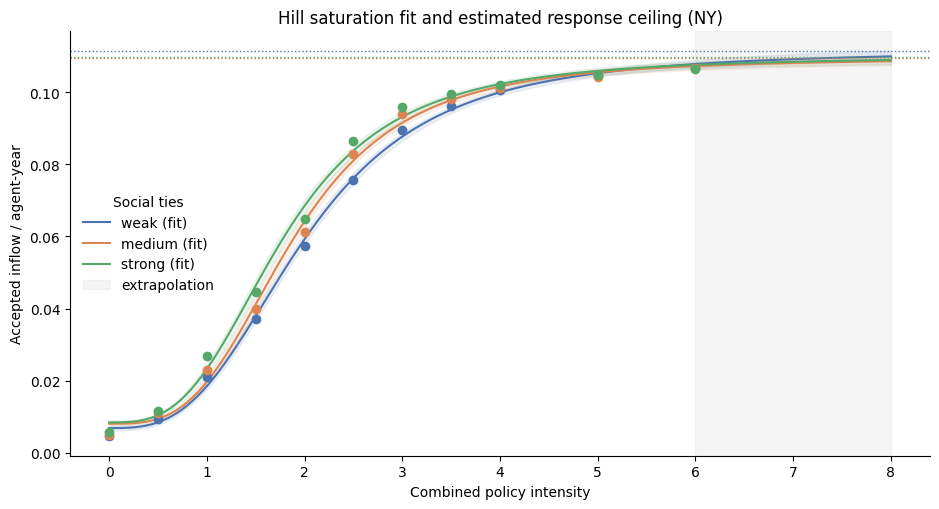

In [21]:
HILL_BOOTSTRAP = 300
SWEEP_X_MAX = float(sweep_summary["policy_intensity"].max())
hill_rows, hill_boot = [], {}
rng_hill = np.random.default_rng(RANDOM_SEED)
seed_col = seed_column(sweep_runs)

for label in ["weak", "medium", "strong"]:
    g = sweep_summary[sweep_summary["interaction"] == label].sort_values("policy_intensity")
    y0, A, K, n = fit_hill(g["policy_intensity"], g["target_inflow_rate"])
    ceiling = y0 + A
    observed_at_max = float(g["target_inflow_rate"].iloc[-1])
    gain_at_max = observed_at_max - y0
    # Bootstrap over seeds: resample seeds, rebuild the mean curve, refit.
    boot = []
    runs = sweep_runs[sweep_runs["interaction"] == label]
    if seed_col is not None and runs[seed_col].nunique() > 1:
        seeds = runs[seed_col].unique()
        for _ in range(HILL_BOOTSTRAP):
            pick = rng_hill.choice(seeds, size=len(seeds), replace=True)
            sample = pd.concat([runs[runs[seed_col] == s] for s in pick])
            curve = sample.groupby("policy_intensity")["target_inflow_rate"].mean()
            try:
                b = fit_hill(curve.index.to_numpy(), curve.to_numpy())
                boot.append(b)
            except RuntimeError:
                continue
    boot = np.array(boot)
    hill_boot[label] = boot
    ceiling_lo = ceiling_hi = K_lo = K_hi = np.nan
    if len(boot):
        ceiling_lo, ceiling_hi = np.percentile(boot[:, 0] + boot[:, 1], [2.5, 97.5])
        K_lo, K_hi = np.percentile(boot[:, 2], [2.5, 97.5])
    # Intensity at which the fitted curve reaches 90% / 95% of its gain A.
    x90 = K * (0.90 / 0.10) ** (1.0 / n)
    x95 = K * (0.95 / 0.05) ** (1.0 / n)
    share_reached = gain_at_max / A if A > 0 else np.nan
    if K > SWEEP_X_MAX:
        verdict = "ceiling extrapolated (K beyond grid) - extend sweep"
    elif share_reached >= 0.95:
        verdict = "plateau reached within grid"
    else:
        verdict = "still rising - extend sweep"
    hill_rows.append({
        "interaction": label, "baseline_y0": y0, "fitted_ceiling": ceiling,
        "ceiling_ci_low": ceiling_lo, "ceiling_ci_high": ceiling_hi,
        "half_response_K": K, "K_ci_low": K_lo, "K_ci_high": K_hi, "hill_n": n,
        "intensity_90pct_gain": x90, "intensity_95pct_gain": x95,
        f"share_of_gain_at_{SWEEP_X_MAX:g}": share_reached,
        "n_bootstrap_fits": len(boot), "verdict": verdict,
    })

hill_summary = pd.DataFrame(hill_rows)
display(hill_summary.round(4))

fig, ax = plt.subplots(figsize=(9.5, 5.2))
x_ext = np.linspace(0, max(8.0, SWEEP_X_MAX), 300)
for label in ["weak", "medium", "strong"]:
    g = sweep_summary[sweep_summary["interaction"] == label].sort_values("policy_intensity")
    row = hill_summary.set_index("interaction").loc[label]
    params = row[["baseline_y0", "fitted_ceiling", "half_response_K", "hill_n"]].to_numpy(dtype=float)
    params[1] = params[1] - params[0]  # ceiling -> A
    color = INTERACTION_COLORS[label]
    ax.scatter(g["policy_intensity"], g["target_inflow_rate"], color=color, zorder=3)
    ax.plot(x_ext, hill_with_baseline(x_ext, *params), color=color, label=f"{label} (fit)")
    ax.axhline(row["fitted_ceiling"], color=color, linestyle=":", linewidth=1)
    boot = hill_boot[label]
    if len(boot):
        band = np.array([hill_with_baseline(x_ext, *b) for b in boot])
        lo, hi = np.percentile(band, [2.5, 97.5], axis=0)
        ax.fill_between(x_ext, lo, hi, color=color, alpha=0.10)
ax.axvspan(SWEEP_X_MAX, x_ext.max(), color="grey", alpha=0.08, label="extrapolation")
ax.set_xlabel("Combined policy intensity")
ax.set_ylabel("Accepted inflow / agent-year")
ax.set_title(f"Hill saturation fit and estimated response ceiling ({FOCAL_STATE})")
ax.legend(title="Social ties", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

### 10.3 Cost reference (downgraded: table only)

For scale, the combined intensity is converted with the Tulsa reference from 10.1 (1 unit = \$10,000 per accepted mover). Spending is paid to every accepted mover, so the marginal cost of an extra mover is Δ total spending / Δ inflow. The marginal cost roughly doubles by intensity 1.5 and exceeds \$100k per extra mover by 3.5.

This is kept as a reference table rather than a finding. Because the per-mover payment itself rises linearly with intensity, marginal cost rises even where the inflow response is still linear, so an early "cost kink" is largely built into the calculation. The \$10k scale also comes from a cash programme, whereas the combined package is housing + employment support.

In [22]:
COST_KINK_MULTIPLE = 2.0

cost_curve = sweep_summary.sort_values(["interaction", "policy_intensity"]).copy()
cost_curve["dollar_per_mover"] = intensity_to_dollar_equivalent(cost_curve["policy_intensity"])
cost_curve["total_spend_per_agent_year"] = cost_curve["dollar_per_mover"] * cost_curve["target_inflow_rate"]
baseline_inflow = (
    cost_curve[cost_curve["policy_intensity"] == 0]
    .set_index("interaction")["target_inflow_rate"]
)
cost_curve["baseline_inflow"] = cost_curve["interaction"].map(baseline_inflow)
cost_curve["induced_inflow"] = cost_curve["target_inflow_rate"] - cost_curve["baseline_inflow"]
cost_curve["avg_cost_per_induced_mover"] = np.where(
    cost_curve["induced_inflow"] > 0,
    cost_curve["total_spend_per_agent_year"] / cost_curve["induced_inflow"], np.nan,
)
grp = cost_curve.groupby("interaction")
cost_curve["marginal_inflow"] = grp["target_inflow_rate"].diff()
cost_curve["marginal_spend"] = grp["total_spend_per_agent_year"].diff()
cost_curve["marginal_cost_per_additional_mover"] = np.where(
    cost_curve["marginal_inflow"] > 0,
    cost_curve["marginal_spend"] / cost_curve["marginal_inflow"], np.inf,
)
cost_curve.loc[cost_curve["marginal_inflow"].isna(), "marginal_cost_per_additional_mover"] = np.nan

kink_rows = []
for label, g in cost_curve.groupby("interaction"):
    mc = g.dropna(subset=["marginal_cost_per_additional_mover"])
    first_mc = mc["marginal_cost_per_additional_mover"].iloc[0]
    over = mc[mc["marginal_cost_per_additional_mover"] > COST_KINK_MULTIPLE * first_mc]
    kink = float(over["policy_intensity"].iloc[0]) if len(over) else np.nan
    resp90 = threshold_summary.set_index("interaction").loc[label, "response90_median"]
    kink_rows.append({
        "interaction": label,
        "first_step_marginal_cost": first_mc,
        f"cost_kink_intensity_{COST_KINK_MULTIPLE:g}x": kink,
        "cost_kink_dollars_per_mover": intensity_to_dollar_equivalent(kink) if np.isfinite(kink) else np.nan,
        "response90_median": resp90,
        "kink_before_response90": bool(np.isfinite(kink) and kink < resp90),
    })
cost_kink_summary = pd.DataFrame(kink_rows)

display(cost_kink_summary.round(3))
display(cost_curve.pivot(index="policy_intensity", columns="interaction", values="marginal_cost_per_additional_mover")
        .reindex(columns=["weak", "medium", "strong"]).round(0)
        .rename_axis(columns="marginal USD per extra mover"))

,interaction,first_step_marginal_cost,cost_kink_intensity_2x,cost_kink_dollars_per_mover,response90_median,kink_before_response90
0,medium,8985.915,1.5,15000.0,3.50,True
1,strong,10230.769,1.5,15000.0,3.25,True
2,weak,9647.887,1.5,15000.0,4.00,True


marginal USD per extra mover,weak,medium,strong
policy_intensity,,,
0.0,NaN,NaN,NaN
0.5,9648.0,8986.0,10231.0
1.0,14090.0,14616.0,13766.0
1.5,21570.0,21900.0,22618.0
2.0,29286.0,29272.0,30967.0
2.5,40522.0,39135.0,40004.0
3.0,57269.0,67905.0,75411.0
3.5,104395.0,143554.0,174520.0
4.0,147267.0,205351.0,240105.0


### 10.4 Side-effect-weighted optimum (footnote)

A net-benefit index (min–max-scaled inflow minus weighted |social cost| and housing rejection) was checked for an interior "sweet spot". On the 0–4 grid the default weights (0.5 / 0.3) gave an intermediate peak at 3.0, but on the extended 0–6 grid the same weights put the optimum at the top of the grid (6.0), and across a 5 × 5 grid of weights the optimum moves between 0 and 6, landing strictly inside the grid in only 4–40% of weight settings (table below). **No weight-robust optimal intensity was found**, so no sweet-spot claim is made.

In [23]:
NET_W_SOCIAL, NET_W_HOUSING = 0.5, 0.3
W_SOCIAL_GRID = [0.0, 0.25, 0.5, 1.0, 2.0]
W_HOUSING_GRID = [0.0, 0.15, 0.3, 0.6, 1.2]

net_df = sweep_summary.sort_values(["interaction", "policy_intensity"]).copy()
if "target_social_cost" not in net_df.columns:
    social = (
        sweep_runs.groupby(["interaction", "policy_intensity"])["target_social_cost"].mean()
        .rename("target_social_cost").reset_index()
    )
    net_df = net_df.merge(social, on=["interaction", "policy_intensity"], how="left")

g = net_df.groupby("interaction")
net_df["inflow_scaled"] = g["target_inflow_rate"].transform(minmax)
net_df["social_cost_scaled"] = g["target_social_cost"].transform(lambda s: minmax(s.abs()))
net_df["housing_rejection_scaled"] = g["housing_rejection"].transform(minmax)

net_df["net_benefit"] = net_benefit(net_df, NET_W_SOCIAL, NET_W_HOUSING)
x_max = net_df["policy_intensity"].max()
optimal_intensity = net_df.loc[net_df.groupby("interaction")["net_benefit"].idxmax(), ["interaction", "policy_intensity"]]

# Weight sensitivity: where does the optimum sit across the weight grid?
sens_rows = []
for w_s in W_SOCIAL_GRID:
    for w_h in W_HOUSING_GRID:
        tmp = net_df.assign(nb=net_benefit(net_df, w_s, w_h))
        for label, gg in tmp.groupby("interaction"):
            sens_rows.append({"interaction": label, "w_social": w_s, "w_housing": w_h,
                              "optimal_intensity": float(gg.loc[gg["nb"].idxmax(), "policy_intensity"])})
weight_sensitivity = pd.DataFrame(sens_rows)
robustness = weight_sensitivity.groupby("interaction")["optimal_intensity"].agg(
    min="min", median="median", max="max",
    share_interior=lambda s: float(((s > 0) & (s < x_max)).mean()),
).reset_index()
robustness = robustness.merge(optimal_intensity.rename(columns={"policy_intensity": f"optimum_at_{NET_W_SOCIAL}_{NET_W_HOUSING}"}), on="interaction")
display(robustness.round(3))

,interaction,min,median,max,share_interior,optimum_at_0.5_0.3
0,medium,0.0,0.5,6.0,0.12,6.0
1,strong,0.0,0.0,6.0,0.04,6.0
2,weak,0.0,0.5,6.0,0.40,6.0


### 10.5 Single-lever saturation: which lever caps out first?

Section 10 sweeps only the combined package; housing-only and employment-only are measured at a single intensity (1.0). Here each lever is swept **on its own** from 0 to 6 in the focal state (0.5-unit steps to 4, then 5 and 6; all three social-tie levels): `housing`, `employment` and `migration_incentive` are pure single levers (no bundled incentive), and the original `combined` package is included as the reference curve. The grid is extended to 6 so that a lever still rising at 4 is not mistaken for one that has saturated.

The question is not only "how strong" but "which lever should be raised first and which still has headroom". A lever whose target-state housing rejection climbs while its inflow flattens is hitting the capacity wall; a lever that keeps adding inflow at low rejection still has room.

,lever,interaction,baseline,gain_at_1,gain_at_max,fitted_ceiling_gain,half_response_K,hill_n,share_of_ceiling_at_max,response90_median,steepest_low_median
0,combined,medium,0.0049,0.0182,0.1019,0.1045,1.8722,3.2599,0.9747,3.50,1.75
3,employment,medium,0.0049,0.0036,0.0146,0.0175,2.3885,1.6273,0.8300,6.00,1.50
6,housing,medium,0.0049,0.0025,0.0412,1.4135,39.2424,1.8920,0.0292,6.00,4.00
9,migration_incentive,medium,0.0049,0.0033,0.0159,0.0214,3.0520,1.4662,0.7421,6.00,1.75
1,combined,strong,0.0059,0.0210,0.1005,0.1040,1.7731,3.0859,0.9671,3.25,2.00
4,employment,strong,0.0059,0.0035,0.0136,0.0151,1.9227,1.7297,0.9049,5.50,1.00
7,housing,strong,0.0059,0.0030,0.0538,1.5391,27.5641,2.2099,0.0349,6.00,5.00
10,migration_incentive,strong,0.0059,0.0036,0.0148,0.0200,2.7833,1.3215,0.7395,5.00,1.00
2,combined,weak,0.0046,0.0166,0.1020,0.1069,1.9981,3.0039,0.9542,4.00,1.75
5,employment,weak,0.0046,0.0034,0.0138,0.0159,2.0705,1.7594,0.8666,4.50,0.50


gain at 6,weak,medium,strong
lever,,,
combined,0.1020,0.1019,0.1005
employment,0.0138,0.0146,0.0136
housing,0.0331,0.0412,0.0538
migration_incentive,0.0160,0.0159,0.0148


response90 (6 = censored),weak,medium,strong
lever,,,
combined,4.0,3.5,3.25
employment,4.5,6.0,5.50
housing,6.0,6.0,6.00
migration_incentive,6.0,6.0,5.00


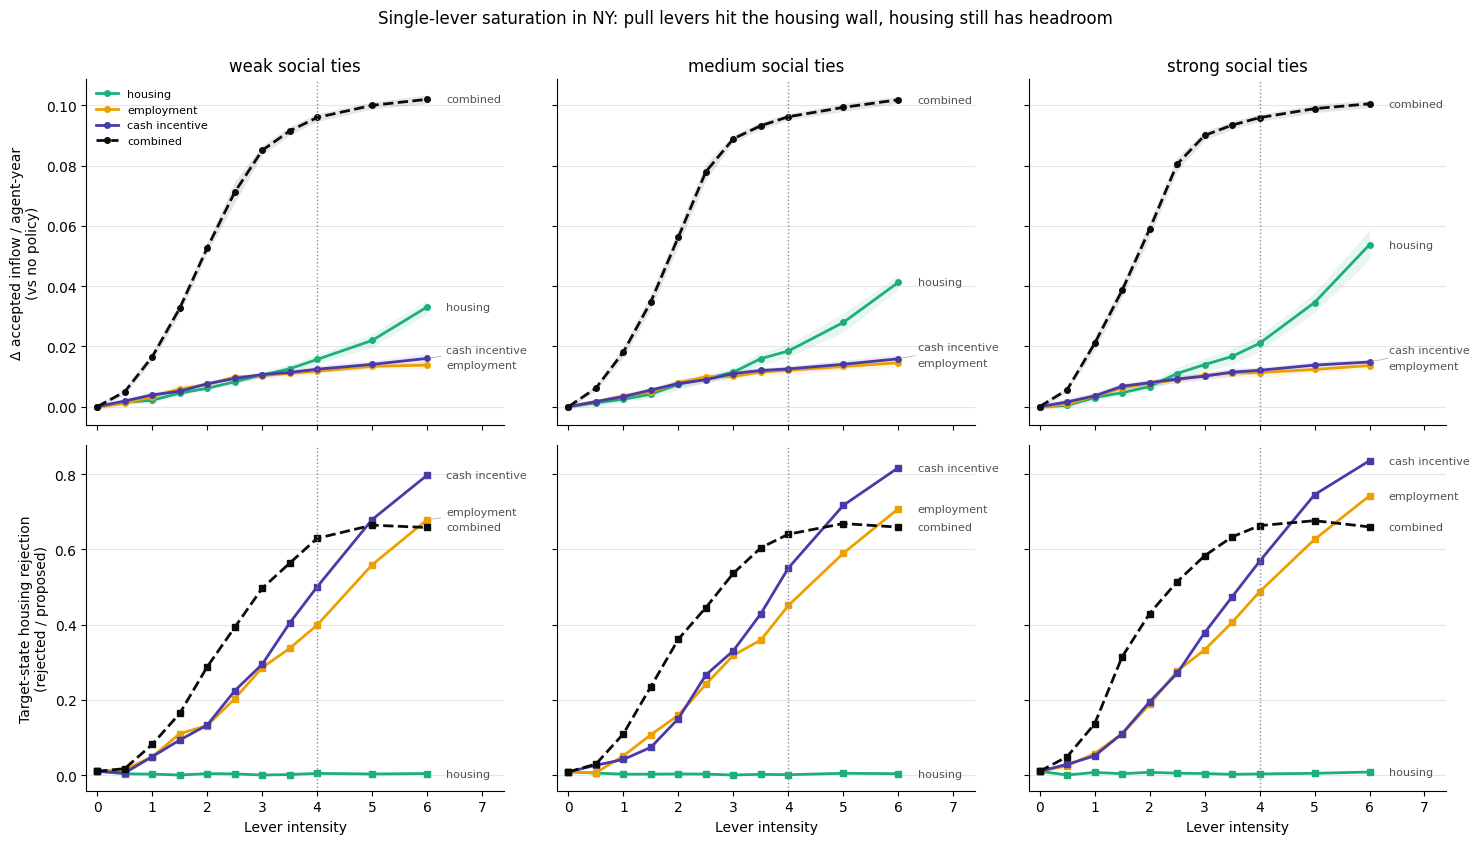

In [24]:
LEVER_STYLES = {
    "housing": {"color": "#1baf7a"}, "employment": {"color": "#eda100"},
    "migration_incentive": {"color": "#4a3aa7"}, "combined": {"color": "#0b0b0b", "linestyle": "--"},
}
LEVER_LABELS = {"housing": "housing", "employment": "employment", "migration_incentive": "cash incentive", "combined": "combined"}

lever_summary = lever_runs.groupby(["lever", "interaction", "intensity"]).agg(
    target_inflow_rate=("target_inflow_rate", "mean"),
    target_inflow_ci95=("target_inflow_rate", lambda s: mean_t_ci(s)[1]),
    housing_rejection=("housing_rejection", "mean"),
    job_rejection=("job_rejection", "mean"),
    chain_share=("chain_share", "mean"),
).reset_index()
lever_saturation = saturation_table(lever_runs, ["lever", "interaction"])
display(lever_saturation.sort_values(["interaction", "lever"]).round(4))
display(lever_saturation.pivot(index="lever", columns="interaction", values="gain_at_max")
        .reindex(columns=SWEEP_INTERACTIONS).round(4).rename_axis(columns=f"gain at {max(EXTENDED_INTENSITIES):g}"))
display(lever_saturation.pivot(index="lever", columns="interaction", values="response90_median")
        .reindex(columns=SWEEP_INTERACTIONS).rename_axis(columns="response90 (6 = censored)"))

# Row 1: inflow gain; row 2: target-state housing rejection; one column per tie level.
fig, axes = plt.subplots(2, 3, figsize=(15.0, 8.4), sharex=True, sharey="row")
ends = {}
for j, inter in enumerate(SWEEP_INTERACTIONS):
    for lever in LEVERS:
        g = lever_summary[(lever_summary["lever"] == lever) & (lever_summary["interaction"] == inter)]
        base = g["target_inflow_rate"].iloc[0]
        style = LEVER_STYLES[lever]
        gain = g["target_inflow_rate"] - base
        axes[0, j].plot(g["intensity"], gain, marker="o", ms=4, lw=2, label=LEVER_LABELS[lever], **style)
        axes[0, j].fill_between(g["intensity"], gain - g["target_inflow_ci95"], gain + g["target_inflow_ci95"],
                                color=style["color"], alpha=0.10, lw=0)
        axes[1, j].plot(g["intensity"], g["housing_rejection"], marker="s", ms=4, lw=2, label=LEVER_LABELS[lever], **style)
        ends.setdefault((0, j), []).append((gain.iloc[-1], LEVER_LABELS[lever]))
        ends.setdefault((1, j), []).append((g["housing_rejection"].iloc[-1], LEVER_LABELS[lever]))
    axes[0, j].set_title(f"{inter} social ties")
    axes[1, j].set_xlabel("Lever intensity")
for ax in axes.ravel():
    ax.axvline(4.0, color="#8c8c8c", linestyle=":", linewidth=1)
    ax.set_xlim(-0.2, 7.4)
    ax.grid(axis="y", color="#e6e6e3", linewidth=0.8); ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
axes[0, 0].set_ylabel("Δ accepted inflow / agent-year\n(vs no policy)")
axes[1, 0].set_ylabel("Target-state housing rejection\n(rejected / proposed)")
axes[0, 0].legend(frameon=False, fontsize=8, loc="upper left")
for (r, j), items in ends.items():
    spread_labels(axes[r, j], items, max(EXTENDED_INTENSITIES))
fig.suptitle(f"Single-lever saturation in {FOCAL_STATE}: pull levers hit the housing wall, housing still has headroom", y=1.0)
plt.tight_layout(); plt.show()

### 10.6 Target-state heterogeneity: is the saturation point the same everywhere?

All previous sweeps target one mechanically chosen state (`FOCAL_STATE`). Here each of the eight states in turn receives the original combined package over the same 0–6 grid, under all three social-tie levels. If the saturation intensity or the ceiling differs a lot across states, "how strong must the policy be" has no single answer: it depends on the target state's own market conditions. The last panel relates each state's response to its housing-capacity and rent indices, the two conditions most likely to set a hard limit.

,target_state,interaction,baseline,gain_at_1,gain_at_max,fitted_ceiling_gain,half_response_K,hill_n,share_of_ceiling_at_max,response90_median,steepest_low_median,housing_capacity_index,rent_index,vacancy_rate,youth_pop_weight,gain_relative_to_baseline,housing_rejection_at_max
0,CA,medium,0.0063,0.0240,0.0875,0.0885,1.4009,3.0660,0.9887,3.0,1.00,0.7684,1.2592,0.0720,2.1471,13.8898,0.5077
3,FL,medium,0.0061,0.0277,0.1012,0.1027,1.4548,2.9113,0.9849,3.0,1.25,1.5170,1.0866,0.1421,1.0782,16.4633,0.6219
18,TX,medium,0.0069,0.0255,0.0920,0.0928,1.3976,3.0624,0.9913,3.0,1.00,0.9767,0.8932,0.0915,1.7002,13.3476,0.5589
15,NY,medium,0.0049,0.0182,0.1019,0.1045,1.8722,3.2599,0.9747,3.5,1.75,1.0165,0.9867,0.0952,1.0368,20.7350,0.6592
6,IL,medium,0.0043,0.0117,0.1032,0.1089,2.4640,3.6571,0.9477,4.0,2.50,0.7794,0.7826,0.0730,0.6546,24.2653,0.7243
12,NC,medium,0.0043,0.0143,0.1036,0.1095,2.2764,3.4049,0.9457,4.0,2.50,1.2573,0.7870,0.1178,0.5722,23.9598,0.7285
21,WA,medium,0.0036,0.0093,0.1030,0.1115,2.9486,3.9681,0.9231,4.5,3.00,0.8265,1.0942,0.0774,0.4279,28.9317,0.7725
9,MA,medium,0.0041,0.0078,0.1022,0.1121,3.0517,3.8590,0.9114,5.0,3.00,0.8582,1.1106,0.0804,0.3831,24.6318,0.7817


response90,weak,medium,strong
target_state,,,
CA,3.0,3.0,2.75
FL,3.5,3.0,3.00
TX,3.5,3.0,2.75
NY,4.0,3.5,3.25
IL,4.0,4.0,4.00
NC,4.0,4.0,3.50
WA,5.0,4.5,4.00
MA,5.0,5.0,4.50


interaction                                      weak  medium  strong
outcome                  state_feature                               
gain_at_max              housing_capacity_index  0.12    0.12    0.19
                         rent_index             -0.55   -0.55   -0.29
                         vacancy_rate            0.12    0.12    0.19
                         youth_pop_weight       -0.79   -0.79   -0.90
housing_rejection_at_max housing_capacity_index  0.05    0.05    0.05
                         rent_index             -0.05   -0.05   -0.05
                         vacancy_rate            0.05    0.05    0.05
                         youth_pop_weight       -1.00   -1.00   -1.00
response90_median        housing_capacity_index -0.02   -0.18   -0.13
                         rent_index             -0.04    0.01   -0.07
                         vacancy_rate           -0.02   -0.18   -0.13
                         youth_pop_weight       -0.96   -0.97   -0.95

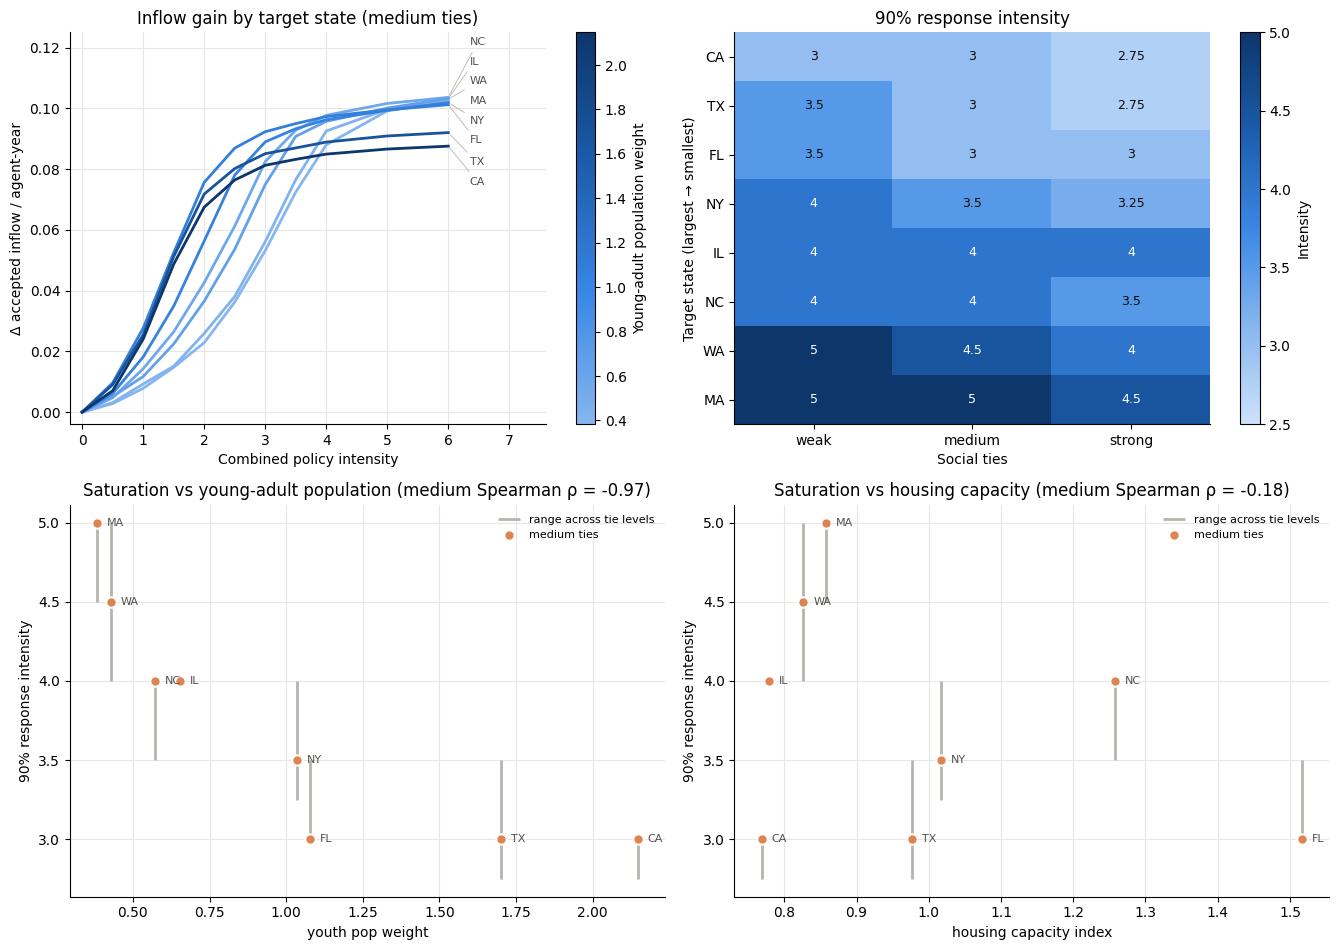

In [25]:
state_cases = [(state, "combined", x, inter, seed)
               for state in STATE_CODES for x in EXTENDED_INTENSITIES
               for inter in SWEEP_INTERACTIONS for seed in SWEEP_SEEDS]
state_runs = cached_or_run("state_intensity_sweep_runs.csv", state_cases)
state_saturation = saturation_table(state_runs, ["target_state", "interaction"])
state_saturation = state_saturation.merge(
    state_data[["housing_capacity_index", "rent_index", "vacancy_rate", "youth_pop_weight"]],
    left_on="target_state", right_index=True,
)
state_saturation["gain_relative_to_baseline"] = state_saturation["gain_at_max"] / state_saturation["baseline"]
state_rejection = (state_runs[state_runs["intensity"] == max(EXTENDED_INTENSITIES)]
                   .groupby(["target_state", "interaction"])["housing_rejection"].mean()
                   .rename("housing_rejection_at_max").reset_index())
state_saturation = state_saturation.merge(state_rejection, on=["target_state", "interaction"])
display(state_saturation[state_saturation["interaction"] == "medium"]
        .sort_values("response90_median").round(4))
display(state_saturation.pivot(index="target_state", columns="interaction", values="response90_median")
        .reindex(columns=SWEEP_INTERACTIONS).sort_values("medium").rename_axis(columns="response90"))

from scipy.stats import spearmanr
corr_rows = []
for inter, gi in state_saturation.groupby("interaction"):
    for col in ["housing_capacity_index", "rent_index", "vacancy_rate", "youth_pop_weight"]:
        for outcome in ["response90_median", "gain_at_max", "housing_rejection_at_max"]:
            rho, p = spearmanr(gi[col], gi[outcome])
            corr_rows.append({"interaction": inter, "state_feature": col, "outcome": outcome, "spearman_rho": rho, "p_value": p})
state_correlations = pd.DataFrame(corr_rows)
display(state_correlations.pivot_table(index=["outcome", "state_feature"], columns="interaction", values="spearman_rho")
        .reindex(columns=SWEEP_INTERACTIONS).round(2))
med = state_saturation[state_saturation["interaction"] == "medium"].set_index("target_state")

from matplotlib.colors import LinearSegmentedColormap, Normalize
SEQ_BLUE = LinearSegmentedColormap.from_list("seq_blue", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
pop = state_data["youth_pop_weight"]
line_norm = Normalize(pop.min(), pop.max())
line_cmap = LinearSegmentedColormap.from_list("seq_blue_lines", ["#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])

state_curves = state_runs[state_runs["interaction"] == "medium"].groupby(["target_state", "intensity"])["target_inflow_rate"].mean().reset_index()
fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.6))
ax = axes[0, 0]
state_ends = []
for state in pop.sort_values().index:
    g = state_curves[state_curves["target_state"] == state]
    gain = g["target_inflow_rate"] - g["target_inflow_rate"].iloc[0]
    ax.plot(g["intensity"], gain, lw=2, color=line_cmap(line_norm(pop[state])))
    state_ends.append((gain.iloc[-1], state))
ax.set_xlim(-0.2, 7.6); ax.set_ylim(-0.004, 0.125)
spread_labels(ax, state_ends, max(EXTENDED_INTENSITIES), min_gap_frac=0.05)
sm = plt.cm.ScalarMappable(norm=line_norm, cmap=line_cmap)
fig.colorbar(sm, ax=ax, label="Young-adult population weight")
ax.set_title("Inflow gain by target state (medium ties)")
ax.set_xlabel("Combined policy intensity"); ax.set_ylabel("Δ accepted inflow / agent-year")

ax = axes[0, 1]
heat = state_saturation.pivot(index="target_state", columns="interaction", values="response90_median").reindex(columns=SWEEP_INTERACTIONS)
heat = heat.loc[pop.sort_values(ascending=False).index]
im = ax.imshow(heat.to_numpy(), aspect="auto", cmap=SEQ_BLUE, vmin=2.5, vmax=5.0)
ax.set_xticks(range(heat.shape[1]), heat.columns); ax.set_yticks(range(heat.shape[0]), heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.iloc[i, j]
        ax.text(j, i, f"{v:g}", ha="center", va="center", fontsize=9, color="#ffffff" if v >= 4.0 else "#0b0b0b")
ax.set_xlabel("Social ties"); ax.set_ylabel("Target state (largest → smallest)")
ax.set_title("90% response intensity"); fig.colorbar(im, ax=ax, label="Intensity")

for ax, feature, title in [
    (axes[1, 0], "youth_pop_weight", "Saturation vs young-adult population"),
    (axes[1, 1], "housing_capacity_index", "Saturation vs housing capacity"),
]:
    # One point per state (medium ties); the vertical bar spans the strong-to-weak range.
    rng_ties = state_saturation.groupby("target_state")["response90_median"].agg(["min", "max"])
    med_i = state_saturation[state_saturation["interaction"] == "medium"].set_index("target_state")
    ax.vlines(med_i[feature], rng_ties.loc[med_i.index, "min"], rng_ties.loc[med_i.index, "max"],
              color="#b5b4ae", linewidth=2, label="range across tie levels", zorder=2)
    ax.scatter(med_i[feature], med_i["response90_median"], s=56, color=INTERACTION_COLORS["medium"],
               edgecolor="#fcfcfb", linewidth=1.5, label="medium ties", zorder=3)
    for state, r in med_i.iterrows():
        ax.annotate(state, (r[feature], r["response90_median"]), xytext=(7, 0),
                    textcoords="offset points", va="center", fontsize=8, color="#52514e")
    rho = state_correlations.query("interaction == 'medium' and state_feature == @feature and outcome == 'response90_median'")["spearman_rho"].iloc[0]
    ax.set_title(f"{title} (medium Spearman ρ = {rho:+.2f})")
    ax.set_xlabel(feature.replace("_", " ")); ax.set_ylabel("90% response intensity")
    ax.legend(frameon=False, fontsize=8)
for ax in axes.ravel():
    ax.spines[["top", "right"]].set_visible(False)
for ax in [axes[0, 0], axes[1, 0], axes[1, 1]]:
    ax.grid(color="#e6e6e3", linewidth=0.8); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

## 11. Step 3 — extreme shocks

The migration system is exposed to exogenous shocks that change job slots, wages, mortality, or migration cost at specified years and then allow gradual recovery. The substantive case is the **labour shortage**: unfilled job slots rise from 0.19 in the no-shock baseline to 21.5, while the move rate barely changes (0.041 → 0.038). Migration within the eight-state system does not fill a structural labour shortage.

*Footnote.* Financial-crisis and pandemic-like shocks were also tested. Both moved the system move rate by less than one percentage point (0.046 and 0.040 vs 0.041 at baseline; the financial-crisis change is about 12% in relative terms, and no seed-level interval is reported) and left clustering, housing rejection and the social utility index essentially unchanged. They remain in the summary table but are not interpreted further.

In [26]:
shock_runs = pd.read_csv(RESULTS_DIR / "shock_runs.csv")
shock_summary = pd.read_csv(RESULTS_DIR / "shock_summary.csv")
display(shock_summary.round(3))

,shock,move_rate,clustering,housing_rejection,social_utility_index,unfilled_jobs
0,baseline,0.041,0.160,0.036,0.338,0.189
1,financial_crisis,0.046,0.162,0.039,0.338,0.233
2,labor_shortage,0.038,0.162,0.034,0.340,21.511
3,pandemic,0.040,0.162,0.040,0.338,0.278


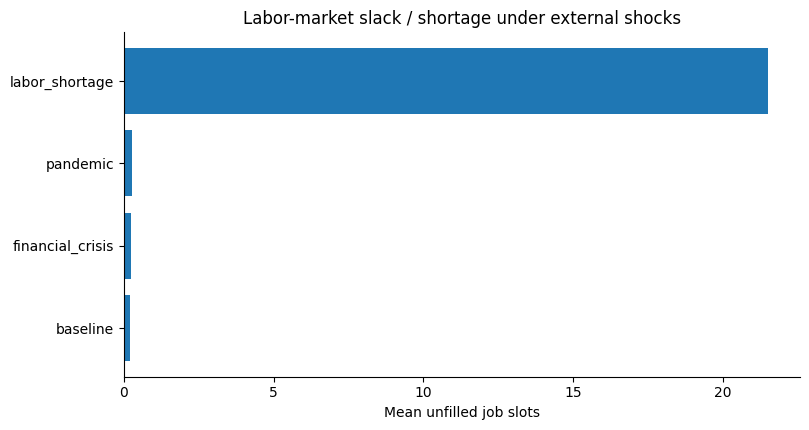

In [27]:
fig, ax = plt.subplots(figsize=(8.2, 4.4))
g = shock_summary.sort_values("unfilled_jobs")
ax.barh(g["shock"], g["unfilled_jobs"])
ax.set_xlabel("Mean unfilled job slots")
ax.set_title("Labor-market slack / shortage under external shocks")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 12. Static interstate competition (footnote)

A stylised static scenario gave every state a different direct migration incentive, generated mechanically from each state's relative housing capacity and job conditions. It produced no substantive finding and is kept only as a footnote:

- Final-year net migration stays within ±2.5 agents per state (in a system of about 600 agents) and no seed-level interval is available.
- The ranking largely restates the incentive rule: the gainers (FL, NC) are the states with the highest housing capacity, and net migration tracks the housing-capacity index (Spearman ρ = +0.78, n = 8), which is itself an input to the incentives.
- Mean employment (0.80) and unfilled jobs (0) are identical across states, so the scenario adds no labour-market contrast.

A dynamic government-response game remains an extension.

In [28]:
competition_summary = pd.read_csv(RESULTS_DIR / "state_competition_summary.csv")
# Employment and unfilled jobs are identical across states in this scenario, so only net migration is shown.
display(competition_summary[["state", "mean_net_migration"]].sort_values("mean_net_migration").round(2))

,state,mean_net_migration
2,IL,-1.33
0,CA,-1.17
5,NY,-1.00
6,TX,-1.00
7,WA,-0.50
3,MA,0.50
4,NC,2.00
1,FL,2.50


## 13. Step 4 - robustness and sensitivity

Robustness is treated as part of the substantive analysis, not an appendix. The notebook tests entrant initialization, social-satisfaction threshold, initial network homophily, lagged rent feedback, and stay preference. The earlier grid also varied a policy-effect scale; that dimension asks the same question as the Section 10 intensity sweep and showed no interaction with stay preference (inflow rose 46–53% from scale 0.75 to 1.25 at every stay setting), so it is held at its central value and not interpreted separately. The objective is to identify which findings are structural and which depend on a narrow parameter choice.

In [29]:
entrant_robustness = pd.read_csv(RESULTS_DIR / "entrant_robustness_runs.csv")
entrant_summary = entrant_robustness.groupby(["home_local", "network_home_bias"]).agg(
    clustering=("coorigin_clustering", "mean"),
    peer_colocation=("peer_colocation", "mean"),
    move_rate=("move_rate", "mean"),
).reset_index()
display(entrant_summary.round(3))

,home_local,network_home_bias,clustering,peer_colocation,move_rate
0,False,False,0.163,0.169,0.042
1,False,True,0.164,0.169,0.042
2,True,False,0.570,0.171,0.035
3,True,True,0.627,0.368,0.033


### Assumption robustness: entrant rules, social threshold, and network homophily

Three robustness checks target assumptions that could otherwise manufacture the headline mechanisms:

1. entrant home-state/network rules (existing 2×2 design);
2. the social-dissatisfaction threshold (`0.20 / 0.35 / 0.50`);
3. initial network homophily (`0.0` random versus `0.5` same-home preference).

The purpose is not to find the setting that gives the most dramatic result, but to see whether the qualitative conclusions survive plausible alternative assumptions.

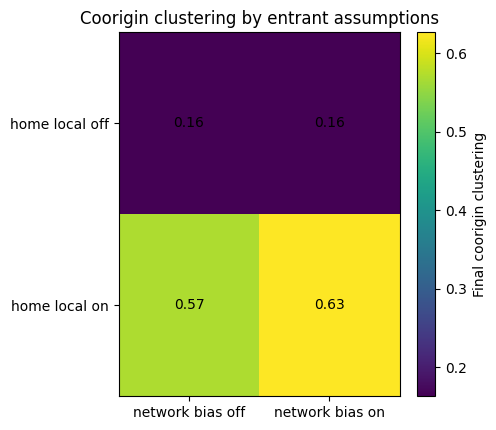

,threshold,scenario,move_rate,clustering,target_inflow,chain_share
0,0.20,baseline,0.035,0.163,0.004,0.063
1,0.20,combined,0.047,0.186,0.021,0.374
2,0.35,baseline,0.041,0.164,0.005,0.117
3,0.35,combined,0.050,0.191,0.023,0.419
4,0.50,baseline,0.047,0.166,0.006,0.179
5,0.50,combined,0.057,0.196,0.026,0.447


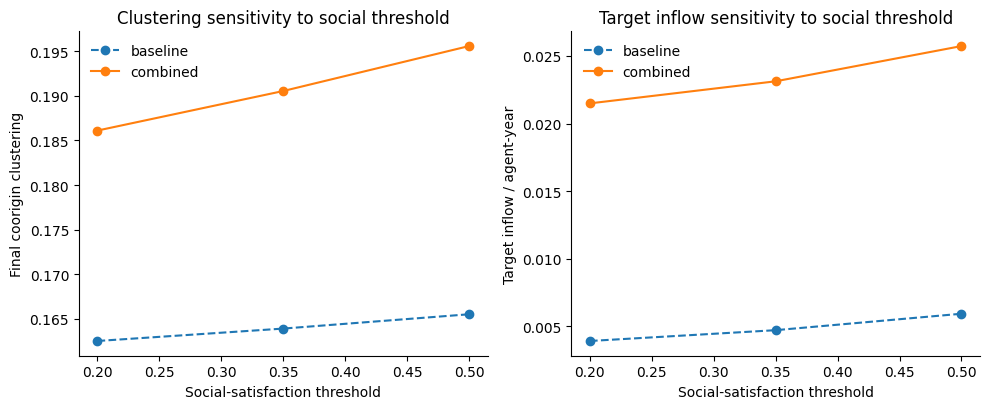

,network_homophily_share,scenario,clustering,peer_colocation,target_inflow,chain_share
0,0.0,baseline,0.164,0.169,0.005,0.117
1,0.0,combined,0.191,0.206,0.023,0.419
2,0.5,baseline,0.165,0.166,0.005,0.183
3,0.5,combined,0.196,0.216,0.024,0.430


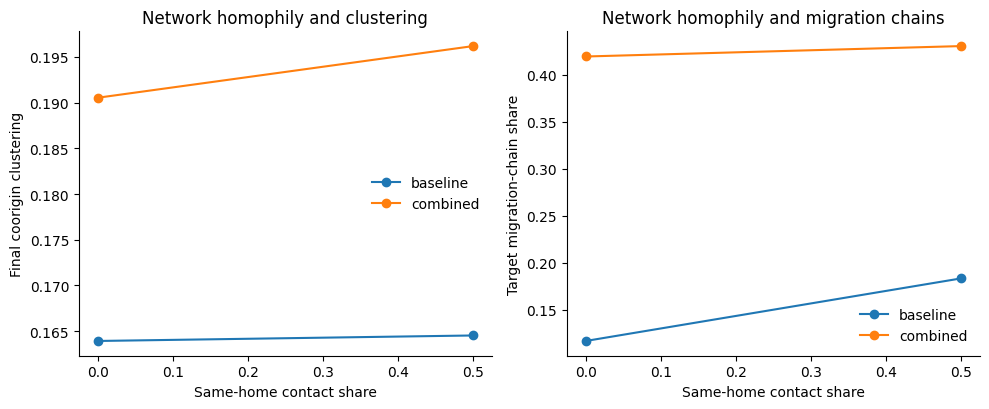

In [30]:
# Entrant-assumption sensitivity heatmap.
pivot = entrant_robustness.pivot_table(index="home_local", columns="network_home_bias", values="coorigin_clustering", aggfunc="mean").reindex(index=[False, True], columns=[False, True])
fig, ax = plt.subplots(figsize=(5.0, 4.4)); im=ax.imshow(pivot.to_numpy(), aspect="auto")
ax.set_xticks([0,1],["network bias off","network bias on"]); ax.set_yticks([0,1],["home local off","home local on"])
for i in range(2):
    for j in range(2): ax.text(j,i,f"{pivot.iloc[i,j]:.2f}",ha="center",va="center")
ax.set_title("Coorigin clustering by entrant assumptions"); fig.colorbar(im,ax=ax,label="Final coorigin clustering"); plt.tight_layout(); plt.show()

threshold_sensitivity = pd.read_csv(RESULTS_DIR / "social_threshold_sensitivity_runs.csv")
threshold_sensitivity_summary = pd.read_csv(RESULTS_DIR / "social_threshold_sensitivity_summary.csv")
display(threshold_sensitivity_summary.round(3))
fig, axes = plt.subplots(1,2,figsize=(10.0,4.2))
for scenario,ls in [("baseline","--"),("combined","-")]:
    g=threshold_sensitivity_summary[threshold_sensitivity_summary.scenario==scenario]
    axes[0].plot(g.threshold,g.clustering,marker="o",linestyle=ls,label=scenario)
    axes[1].plot(g.threshold,g.target_inflow,marker="o",linestyle=ls,label=scenario)
axes[0].set_title("Clustering sensitivity to social threshold"); axes[0].set_ylabel("Final coorigin clustering")
axes[1].set_title("Target inflow sensitivity to social threshold"); axes[1].set_ylabel("Target inflow / agent-year")
for ax in axes: ax.set_xlabel("Social-satisfaction threshold"); ax.legend(frameon=False); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

network_homophily_runs = pd.read_csv(RESULTS_DIR / "network_homophily_runs.csv")
network_homophily_summary = pd.read_csv(RESULTS_DIR / "network_homophily_summary.csv")
display(network_homophily_summary.round(3))
fig, axes = plt.subplots(1,2,figsize=(10.0,4.2))
for scenario in ["baseline","combined"]:
    g=network_homophily_summary[network_homophily_summary.scenario==scenario]
    axes[0].plot(g.network_homophily_share,g.clustering,marker="o",label=scenario)
    axes[1].plot(g.network_homophily_share,g.chain_share,marker="o",label=scenario)
axes[0].set_title("Network homophily and clustering"); axes[0].set_ylabel("Final coorigin clustering")
axes[1].set_title("Network homophily and migration chains"); axes[1].set_ylabel("Target migration-chain share")
for ax in axes: ax.set_xlabel("Same-home contact share"); ax.legend(frameon=False); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

In [31]:
sensitivity_runs = pd.read_csv(RESULTS_DIR / "parameter_sensitivity_runs.csv")
# Only the stay-preference dimension is interpreted; the policy-effect scale is held at 1.0
# (it overlaps with the Section 10 intensity sweep).
stay_sensitivity = sensitivity_runs[sensitivity_runs["policy_scale"] == 1.0].groupby("stay_scale").agg(
    target_inflow=("target_inflow_rate","mean"), social_cost=("target_social_cost","mean"),
    chain_share=("target_chain_share","mean"), clustering=("coorigin_clustering","mean"),
).reset_index()
display(stay_sensitivity.round(3))

,stay_scale,target_inflow,social_cost,chain_share,clustering
0,0.85,0.032,-0.128,0.493,0.213
1,1.00,0.023,-0.109,0.419,0.191
2,1.15,0.014,-0.089,0.283,0.174


### Housing-price feedback

The rent-feedback elasticity is scanned around the central value 0.15, including `0.0` as the old no-price-feedback control.

V7 uses a **hybrid soft-capacity market** rather than a deterministic hard cutoff: acceptance probability declines smoothly when remaining housing capacity is exhausted, and realized rejection feeds into next-year rents. This keeps finite housing as a real constraint while avoiding an artificial one-unit cliff.

,rent_rejection_elasticity,target_inflow,target_housing_rejection,chain_share,final_rent
0,0.00,0.066,0.450,0.750,0.700
1,0.10,0.062,0.418,0.731,0.970
2,0.15,0.060,0.393,0.707,1.187
3,0.20,0.059,0.348,0.711,1.338


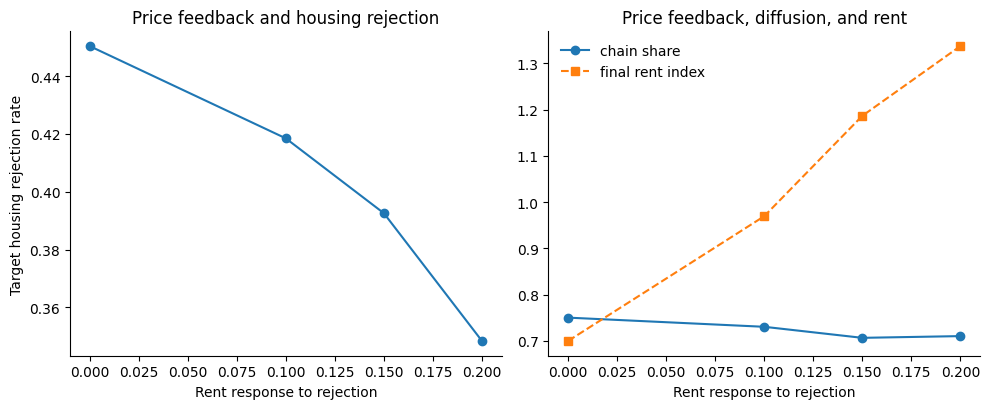

In [32]:
rent_feedback_runs = pd.read_csv(RESULTS_DIR / "rent_feedback_sensitivity_runs.csv")
rent_feedback_summary = pd.read_csv(RESULTS_DIR / "rent_feedback_sensitivity_summary.csv")
display(rent_feedback_summary.round(3))
fig, axes = plt.subplots(1,2,figsize=(10.0,4.2))
axes[0].plot(rent_feedback_summary.rent_rejection_elasticity,rent_feedback_summary.target_housing_rejection,marker="o")
axes[0].set_title("Price feedback and housing rejection"); axes[0].set_xlabel("Rent response to rejection"); axes[0].set_ylabel("Target housing rejection rate")
axes[1].plot(rent_feedback_summary.rent_rejection_elasticity,rent_feedback_summary.chain_share,marker="o",label="chain share")
axes[1].plot(rent_feedback_summary.rent_rejection_elasticity,rent_feedback_summary.final_rent,marker="s",linestyle="--",label="final rent index")
axes[1].set_title("Price feedback, diffusion, and rent"); axes[1].set_xlabel("Rent response to rejection"); axes[1].legend(frameon=False)
for ax in axes: ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

### 13.3 BRFSS directional-validation coverage audit

The review suggested validating the model’s state ranking against BRFSS life satisfaction. V7 first checks whether a common-year eight-state comparison is statistically defensible. The 2023 life-satisfaction item is in BRFSS **Social Determinants and Health Equity** Module 29. CDC’s 2023 module-by-state documentation shows that California, Illinois, Massachusetts, New York (selected questionnaire versions), and North Carolina fielded Social Determinants, while Florida, Texas, and Washington did not.

Therefore an eight-state 2023 Spearman correlation would compare non-comparable missing-by-design samples. V7 **does not manufacture that validation**. The notebook records the coverage audit and treats a complete common-year external subjective-wellbeing validation as future work. This is preferable to reporting a fragile five-state correlation as if it validated all eight states.

Sources: CDC 2023 BRFSS Questionnaire (Module 29) and CDC “2023 Modules by State by Data Set & Weight.”


In [33]:
brfss_coverage = pd.read_csv(RAW_DATA_DIR / "brfss_2023_coverage_audit.csv")
brfss_validation_status = pd.read_csv(RAW_DATA_DIR / "brfss_validation_status.csv")
display(brfss_coverage); display(brfss_validation_status)

,state,social_determinants_module_2023,life_satisfaction_item_comparable
0,CA,True,True
1,TX,False,False
2,NY,True,True
3,FL,False,False
4,MA,True,True
5,NC,True,True
6,IL,True,True
7,WA,False,False


,covered_model_states,total_model_states,complete_eight_state_spearman_estimated,reason
0,5,8,False,2023 Social Determinants module not fielded in...


### 13.4 Distance-decay social networks

The homophily test (0 vs 0.5 same-home contacts) varies *who* agents know but keeps contacts spread across the country. A distance-decay network tests a different mechanism: contacts are drawn with probability ∝ `exp(-decay · d(state_i, state_j) / d_max)`, so most contacts live in the agent's own or nearby states. The rule is applied at initialisation and whenever the model rewires a replacement entrant, so it is not washed out over the run. Decay levels 2 / 5 / 10 raise the share of same-state contacts from 0.19 (random) to about 0.37 / 0.65 / 0.86 at the start of the run.

More local networks also lower the baseline move rate, which would confound the comparison, so each decay level is run twice: with the original `beta_current_state` and with `beta_current_state` re-calibrated (bisection on the calibration seeds) until the no-policy move rate matches the random-network model. The test uses the Section 9 design (combined package at intensity 1.0, all tie levels, cross-experiment seeds).

**Result.** After re-calibration the combined package still multiplies target inflow about 4–5× and about 40–50% of its inflow still arrives through migration chains at every decay level. But the social-tie amplification of the combined effect (strong minus weak) is significant only with the random network; with any geographic locality it is no longer distinguishable from zero once the move rate is re-calibrated. The apparent reversal at decay 10 without re-calibration comes from the depressed move rate, not from the network itself. So the amplification finding depends on contacts being geographically dispersed.

,recalibrated,network_decay,beta_current_state,same_state_contacts_end,baseline_move_rate,combined_inflow_multiple,combined_chain_share,strong_minus_weak,ci95,amplification_significant
0,False,0.0,3.9250,0.1693,0.0404,4.6701,0.4308,0.0046,0.0016,True
1,False,2.0,3.9250,0.3200,0.0320,4.6125,0.3772,0.0018,0.0023,False
2,False,5.0,3.9250,0.5340,0.0226,5.9603,0.3535,-0.0010,0.0015,False
3,False,10.0,3.9250,0.7372,0.0173,5.7258,0.3076,-0.0034,0.0018,True
4,True,0.0,3.9250,0.1693,0.0404,4.6701,0.4308,0.0046,0.0016,True
5,True,2.0,3.7190,0.2988,0.0405,4.5914,0.4441,0.0017,0.0025,False
6,True,5.0,3.4158,0.5029,0.0411,4.6431,0.4074,-0.0006,0.0013,False
7,True,10.0,3.1838,0.6374,0.0403,4.0868,0.4266,-0.0016,0.0025,False


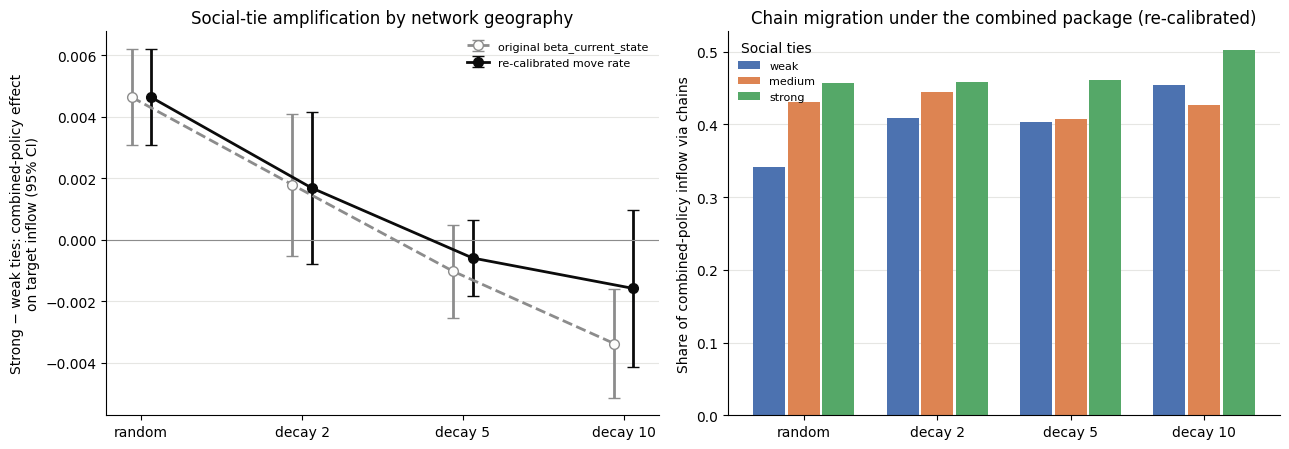

In [34]:
# DistanceDecayABM (src/extensions.py) draws contacts with probability ∝ exp(-decay · d / d_max);
# network_decay_runs() loads the cached runs or re-runs the calibration and cases (src/experiments.py).
from src.extensions import DistanceDecayABM
from src.experiments import run_decay_case, network_decay_runs

decay_runs = network_decay_runs()

med = decay_runs[decay_runs["interaction"] == "medium"]
decay_table = med.pivot_table(index=["recalibrated", "network_decay"], columns="policy",
                              values=["target_inflow_rate", "chain_share", "move_rate", "same_state_contact_share"])
decay_summary = pd.DataFrame({
    "beta_current_state": med.groupby(["recalibrated", "network_decay"])["beta_current_state"].first(),
    "same_state_contacts_end": decay_table[("same_state_contact_share", "baseline")],
    "baseline_move_rate": decay_table[("move_rate", "baseline")],
    "combined_inflow_multiple": decay_table[("target_inflow_rate", "combined")] / decay_table[("target_inflow_rate", "baseline")],
    "combined_chain_share": decay_table[("chain_share", "combined")],
}).reset_index().merge(strong_minus_weak(decay_runs, ["recalibrated", "network_decay"]), on=["recalibrated", "network_decay"])
decay_summary["amplification_significant"] = (decay_summary["strong_minus_weak"].abs() > decay_summary["ci95"])
display(decay_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.6))
ax = axes[0]
for recal, style in [(False, dict(color="#8c8c8c", marker="o", mfc="#fcfcfb", linestyle="--", label="original beta_current_state")),
                     (True, dict(color="#0b0b0b", marker="o", linestyle="-", label="re-calibrated move rate"))]:
    g = decay_summary[decay_summary["recalibrated"] == recal]
    x = np.arange(len(g)) + (0.06 if recal else -0.06)
    ax.errorbar(x, g["strong_minus_weak"], yerr=g["ci95"], capsize=4, lw=2, ms=7, **style)
ax.axhline(0, color="#8c8c8c", lw=0.8)
ax.set_xticks(range(len(NETWORK_DECAYS)), [f"random" if d == 0 else f"decay {d:g}" for d in NETWORK_DECAYS])
ax.set_ylabel("Strong − weak ties: combined-policy effect\non target inflow (95% CI)")
ax.set_title("Social-tie amplification by network geography")
ax.legend(frameon=False, fontsize=8)
ax = axes[1]
g = decay_runs[(decay_runs["recalibrated"]) & (decay_runs["policy"] == "combined")].groupby(["network_decay", "interaction"])["chain_share"].mean().unstack()
for k, inter in enumerate(SWEEP_INTERACTIONS):
    ax.bar(np.arange(len(g)) + (k - 1) * 0.26, g[inter], width=0.24, color=INTERACTION_COLORS[inter], label=inter)
ax.set_xticks(range(len(g)), [f"random" if d == 0 else f"decay {d:g}" for d in g.index])
ax.set_ylabel("Share of combined-policy inflow via chains")
ax.set_title("Chain migration under the combined package (re-calibrated)")
ax.legend(title="Social ties", frameon=False, fontsize=8)
for ax in axes:
    ax.grid(axis="y", color="#e6e6e3", linewidth=0.8); ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

### 13.5 Open system: competition from the other 42 states

Section 3.1 measured that about 62% of interstate in-movers to the eight modelled states come from outside them. The closed model ignores this flow. This check adds a simplified, policy-responsive `OTHER_US` inflow:

- Each year a Poisson number of outside young adults choose a destination with the same state-level utility as insiders, **including all three policy signals**, so a targeted policy also attracts outsiders. They have no in-system origin, so current-state, distance and peer terms are omitted.
- They compete for the housing slots left after internal moves with the same soft acceptance rule, and their rejections feed next-year rent.
- Each accepted arrival replaces a randomly chosen resident who leaves for another state, keeping population constant.
- The arrival rate is calibrated by bisection so that, without policy, outsiders are 62% of accepted in-movers.

Housing capacity is the decisive unknown, so it is bracketed: **shared** (outsiders use the same slots as insiders, an upper bound on crowding) and **scaled** (capacity is 1/(1−0.62) times larger, i.e. the vacancy stock serves all in-movers, a lower bound). The Section 9 design and the medium-tie combined sweep are re-run under both. Target-state inflow is reported as internal (comparable to the closed model) and total (internal + outside arrivals).

**Result.**
- The closed model's **relative** effect of the combined package is an upper bound: ×4.7 over no policy in the closed model versus ×3.9 (scaled) and ×2.0 (shared) for total inflow. In absolute terms the extra inflow ranges from −26% (shared) to +111% (scaled, where the policy also pulls outsiders), so the direction depends on whether housing can absorb outside demand.
- The **housing wall** becomes stronger, not weaker: with shared capacity the employment-only policy adds almost no total inflow (it reshuffles who gets scarce housing), while the housing lever still adds inflow. This reinforces the single-lever result.
- The saturation intensity stays near 3–3.5 for internal inflow; total inflow with shared capacity keeps rising longer (90% response at 5.0).
- Social-tie amplification of internal inflow holds under both brackets; for total inflow it holds with scaled capacity and disappears with shared capacity, where insiders crowd out outsiders.

,capacity_mode,external_rate,external_share_no_policy
0,scaled,0.0691,0.6033
1,shared,0.0983,0.6145


,model,policy,effect_internal,effect_total,multiple_total,housing_rejection
0,closed,housing,0.0061,0.0061,2.2027,0.0080
1,open (scaled),housing,0.0056,0.0126,1.9248,0.0086
2,open (shared),housing,0.0049,0.0100,1.7177,0.2562
3,closed,employment,0.0056,0.0056,2.1100,0.1044
4,open (scaled),employment,0.0063,0.0138,2.0089,0.0689
5,open (shared),employment,0.0037,0.0010,1.0746,0.5212
6,closed,combined,0.0185,0.0185,4.6701,0.1188
7,open (scaled),combined,0.0201,0.0391,3.8713,0.0455
8,open (shared),combined,0.0127,0.0136,1.9776,0.5056


,capacity_mode,strong_minus_weak,ci95,inflow
0,scaled,0.0069,0.0008,inflow
1,shared,0.0043,0.0029,inflow
2,scaled,0.0059,0.0012,total_inflow
3,shared,-0.0009,0.0021,total_inflow
4,closed,0.0046,0.0016,inflow


,model,inflow,response90_median,gain_at_6
0,closed,inflow,3.50,0.1019
1,closed,total_inflow,3.50,0.1019
2,scaled,inflow,3.25,0.0903
3,scaled,total_inflow,3.50,0.1487
4,shared,inflow,3.00,0.0976
5,shared,total_inflow,5.00,0.1437


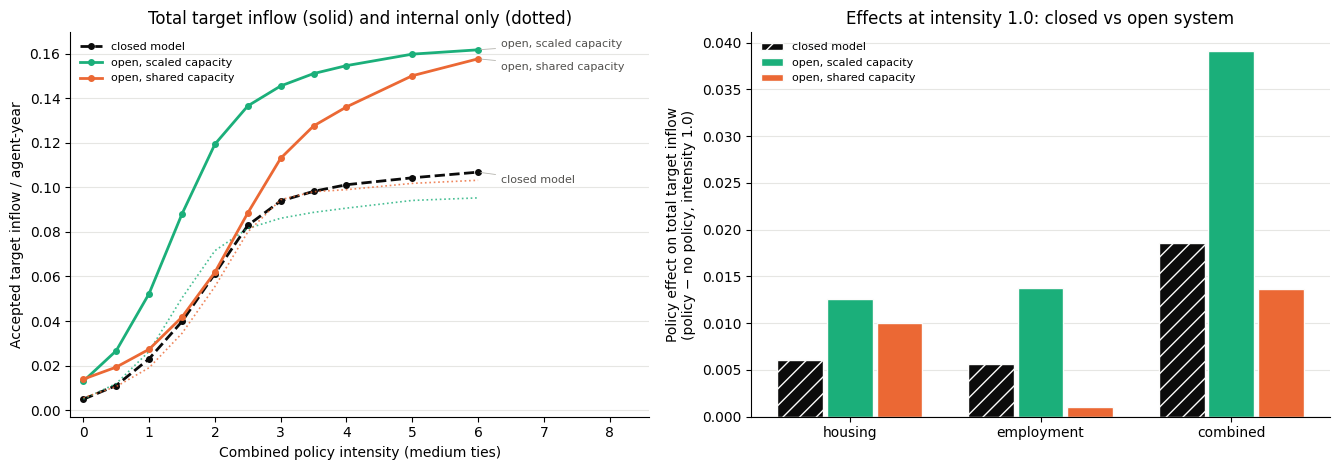

In [35]:
# OpenSystemABM (src/extensions.py) adds a policy-responsive OTHER_US inflow; open_system_runs()
# loads the cached runs or calibrates the external rate and re-runs (src/experiments.py).
from src.experiments import cross_policy, run_open_case, open_system_runs

open_runs = open_system_runs()

# Calibration check and effects at intensity 1.0 (medium ties), against the closed Section 9 results.
cross_open = open_runs[(open_runs["design"] == "cross") & (open_runs["interaction"] == "medium")]
calib = cross_open[cross_open["policy"] == "baseline"].groupby("capacity_mode").agg(
    external_rate=("external_rate", "first"), external_share_no_policy=("external_share_system", "mean")).reset_index()
display(calib.round(4))
closed = cross_summary[cross_summary["interaction"] == "medium"].set_index("policy")
rows = []
for policy in ["housing", "employment", "combined"]:
    base, pol = closed.loc["baseline", "target_inflow_rate"], closed.loc[policy, "target_inflow_rate"]
    rows.append({"model": "closed", "policy": policy, "effect_internal": pol - base, "effect_total": pol - base,
                 "multiple_total": pol / base, "housing_rejection": closed.loc[policy, "housing_rejection"]})
    for mode, g in cross_open.groupby("capacity_mode"):
        m = g.groupby("policy")[["target_inflow_rate", "target_total_inflow_rate", "housing_rejection"]].mean()
        rows.append({"model": f"open ({mode})", "policy": policy,
                     "effect_internal": m.loc[policy, "target_inflow_rate"] - m.loc["baseline", "target_inflow_rate"],
                     "effect_total": m.loc[policy, "target_total_inflow_rate"] - m.loc["baseline", "target_total_inflow_rate"],
                     "multiple_total": m.loc[policy, "target_total_inflow_rate"] / m.loc["baseline", "target_total_inflow_rate"],
                     "housing_rejection": m.loc[policy, "housing_rejection"]})
open_effects = pd.DataFrame(rows)
display(open_effects.round(4))

amp = []
for metric in ["target_inflow_rate", "target_total_inflow_rate"]:
    t_ = strong_minus_weak(open_runs[open_runs["design"] == "cross"], ["capacity_mode"], metric)
    amp.append(t_.assign(inflow=metric.replace("target_", "").replace("_rate", "")))
closed_amp = policy_effects[(policy_effects["policy"] == "combined") & (policy_effects["metric"] == "d_target_inflow_rate")]
amp.append(pd.DataFrame({"capacity_mode": ["closed"], "strong_minus_weak": closed_amp["strong_minus_weak_policy_effect"].to_numpy(),
                         "ci95": closed_amp["ci95_half_width"].to_numpy(), "inflow": ["inflow"]}))
display(pd.concat(amp, ignore_index=True).round(4))

sweep_open = open_runs[open_runs["design"] == "sweep"].rename(columns={"intensity": "policy_intensity"})
closed_sweep = sweep_runs[sweep_runs["interaction"] == "medium"].assign(capacity_mode="closed", target_total_inflow_rate=lambda d: d["target_inflow_rate"])
all_sweep = pd.concat([closed_sweep, sweep_open], ignore_index=True)
sat_rows = []
for mode, g in all_sweep.groupby("capacity_mode"):
    for col in ["target_inflow_rate", "target_total_inflow_rate"]:
        thr = thresholds_by_seed(g, ["capacity_mode"], x_col="policy_intensity", y=col)
        curve = g.groupby("policy_intensity")[col].mean()
        sat_rows.append({"model": mode, "inflow": col.replace("target_", "").replace("_rate", ""),
                         "response90_median": thr["response90"].median(), "gain_at_6": curve.iloc[-1] - curve.iloc[0]})
display(pd.DataFrame(sat_rows).round(4))

MODEL_STYLES = {"closed": dict(color="#0b0b0b", linestyle="--"), "scaled": dict(color="#1baf7a"), "shared": dict(color="#eb6834")}
MODEL_LABELS = {"closed": "closed model", "scaled": "open, scaled capacity", "shared": "open, shared capacity"}
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
ax = axes[0]
end_labels = []
for mode in ["closed", "scaled", "shared"]:
    g = all_sweep[all_sweep["capacity_mode"] == mode].groupby("policy_intensity")[["target_total_inflow_rate", "target_inflow_rate"]].mean()
    ax.plot(g.index, g["target_total_inflow_rate"], marker="o", ms=4, lw=2, label=MODEL_LABELS[mode], **MODEL_STYLES[mode])
    if mode != "closed":
        ax.plot(g.index, g["target_inflow_rate"], lw=1.2, alpha=0.8, color=MODEL_STYLES[mode]["color"], linestyle=":")
    end_labels.append((g["target_total_inflow_rate"].iloc[-1], MODEL_LABELS[mode]))
ax.set_xlim(-0.2, 8.6)
spread_labels(ax, end_labels, max(EXTENDED_INTENSITIES), min_gap_frac=0.06)
ax.set_xlabel("Combined policy intensity (medium ties)")
ax.set_ylabel("Accepted target inflow / agent-year")
ax.set_title("Total target inflow (solid) and internal only (dotted)")
ax.legend(frameon=False, fontsize=8, loc="upper left")
ax = axes[1]
order = ["housing", "employment", "combined"]
for k, mode in enumerate(["closed", "scaled", "shared"]):
    label = "closed" if mode == "closed" else f"open ({mode})"
    g = open_effects[open_effects["model"] == label].set_index("policy").loc[order]
    ax.bar(np.arange(3) + (k - 1) * 0.26, g["effect_total"], width=0.24, color=MODEL_STYLES[mode]["color"],
           hatch="//" if mode == "closed" else None, edgecolor="#fcfcfb", label=MODEL_LABELS[mode])
ax.axhline(0, color="#8c8c8c", lw=0.8)
ax.set_xticks(range(3), order)
ax.set_ylabel("Policy effect on total target inflow\n(policy − no policy, intensity 1.0)")
ax.set_title("Effects at intensity 1.0: closed vs open system")
ax.legend(frameon=False, fontsize=8)
for ax in axes:
    ax.grid(axis="y", color="#e6e6e3", linewidth=0.8); ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

### 13.6 Reproducibility spot check

This results build loads cached seed-level outputs instead of re-simulating everything. To show that the cache matches the model code, a few cases are re-simulated live and compared field by field with the cached rows: two Section 9 cross-experiment cases and two cases from the Section 10 sweeps (another lever and another target state). Any mismatch raises an error, which would mean the cache is stale or the code has changed. The cell also prints the cache file timestamps and the package versions; `requirements.txt` pins the versions this build was verified with.

In [36]:
import importlib.metadata as _md, platform, datetime
from src.experiments import live_summary

# Cached column names differ slightly between batches; compare every metric both sides have.
CROSS_COLUMN_ALIASES = {"target_inflow_rate": ["target_inflow_rate"],
                        "chain_share": ["target_chain_share", "chain_share"],
                        "target_social_cost": ["target_social_cost", "social_cost"],
                        "housing_rejection": ["target_housing_rejection", "housing_rejection"],
                        "coorigin_clustering": ["coorigin_clustering", "clustering"]}

rows = []
for policy in ["baseline", "combined"]:
    seed = CROSS_SEEDS[0]
    cached = cross_runs[(cross_runs["policy"] == policy) & (cross_runs["interaction"] == "medium") & (cross_runs["seed"] == seed)].iloc[0]
    live = live_summary(FOCAL_STATE, cross_policy(policy, STANDARD_INTENSITY), "medium", seed)
    rows.append(compare(f"cross: {policy}, medium, seed {seed}", live, cached, CROSS_COLUMN_ALIASES))
same = {k: [k] for k in ["target_inflow_rate", "target_social_cost", "chain_share", "housing_rejection", "job_rejection", "coorigin_clustering"]}
for runs, target_state, lever, x, inter in [(lever_runs, FOCAL_STATE, "housing", 3.0, "strong"),
                                             (state_runs, "CA", "combined", 2.0, "weak")]:
    seed = SWEEP_SEEDS[0]
    cached = runs[(runs["target_state"] == target_state) & (runs["lever"] == lever) & (runs["intensity"] == x)
                  & (runs["interaction"] == inter) & (runs["seed"] == seed)].iloc[0]
    live = live_summary(target_state, lever_policy(target_state, lever, x), inter, seed)
    rows.append(compare(f"sweep: {target_state} {lever} {x:g}, {inter}, seed {seed}", live, cached, same))
display(pd.DataFrame(rows))

stamps = pd.DataFrame([{"file": p.name, "modified": datetime.datetime.fromtimestamp(p.stat().st_mtime).strftime("%Y-%m-%d %H:%M")}
                       for p in sorted([*RAW_DATA_DIR.glob("*.csv"), *RESULTS_DIR.glob("*.csv")])])
print(f"{len(stamps)} cached CSV files; newest {stamps['modified'].max()}, oldest {stamps['modified'].min()}")
print("Python", platform.python_version(), "|", ", ".join(f"{p} {_md.version(p)}" for p in ["numpy", "pandas", "scipy", "matplotlib", "joblib"]))

,case,metrics_checked,target_inflow_rate,status
0,"cross: baseline, medium, seed 201",5,0.004583,match
1,"cross: combined, medium, seed 201",5,0.022222,match
2,"sweep: NY housing 3, strong, seed 301",6,0.014583,match
3,"sweep: CA combined 2, weak, seed 301",6,0.065972,match


32 cached CSV files; newest 2026-10-05 13:06, oldest 2026-10-05 13:05
Python 3.12.13 | numpy 2.2.6, pandas 2.3.3, scipy 1.15.3, matplotlib 3.10.6, joblib 1.5.3
